<a href="https://colab.research.google.com/github/fmssilva/DL_Proj/blob/main/assignment_1/task1/task1_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pokemon Type Classification | DL Assignment 1

## Task 1 — MLP Baseline

**Goal:** classify 3600 Pokémon images into 9 types using a flat-pixel MLP. This is the *baseline* — intentionally simple, so the gap with CNN (Task 2) is clear and measurable.  

**Metric:** Macro-averaged F1 — used because class imbalance is 2.76× (Water 674 vs Ground 244). Accuracy would be misleading.  

_____________
**DO NOT RUN ALL CELLS**

> This notebook requires some 20 minutes to run all training sequences with T4 GPU. So if you don't have those resources, avoid running it all again and **instead just run the needed specific cells you want.**
______

---

## Table of Contents

- [Part 0 — Project Load](#part-0---project-load)
  - [Config](#config)
  - [Import & Set Up](#import--set-up)
  - [Load Data](#load-data)
- [Part 1 — Exploratory Data Analysis](#part-1--exploratory-data-analysis)
  - [Plot 1 — Class Distribution](#plot-1--class-distribution)
  - [Plot 2 — Sample Images per Class](#plot-2--sample-images-per-class)
  - [Plot 3 — Average Image per Class](#plot-3--average-image-per-class)
  - [Plot 4 — Per-Channel Pixel Statistics](#plot-4--per-channel-pixel-statistics)
  - [Plot 5 — Pixel Intensity Histogram](#plot-5--pixel-intensity-histogram)
  - [Plot 6 — PCA → t-SNE Cluster Plot](#plot-6--pca--t-sne-cluster-plot)
- [Part 2 — Model Experiments](#part-2--model-experiments)
  - [Results Manager](#results-manager)
  - [Setup Experiments](#setup-experiments)
  - [Experiments Plan & Registry](#experiments-plan--registry)
  - [A: Vanilla Baseline](#a-vanilla-baseline)
  - [B: MLP Baseline](#b-mlp-baseline)
  - [C: Dropout(0.3) + label_smoothing=0.1](#c-dropout03--label_smoothing01)
  - [D: + weight_decay=1e-4](#d--weight_decay1e-4)
  - [E: WeightedRandomSampler](#e-weightedrandomsampler)
  - [F: Narrow + Deep MLP](#f-narrow--deep-mlp)
  - [G: Bottleneck MLP](#g-bottleneck-mlp)
  - [H: VanillaMLP_v2 (wider, no regularisation)](#h-vanillamlp_v2-wider-no-regularisation)
  - [I: VanillaMLP_v2 + targeted class weights](#i-vanillamlp_v2--targeted-class-weights-rock--ground)
  - [J: MLP with lighter dropout (0.2)](#j-mlp-with-lighter-dropout-02)
  - [K: VanillaMLP_v2 + tiny L2](#k-vanillamlp_v2--tiny-l2-weight_decay1e-5)
  - [L: WiderMLP (1024 first layer) + winning C recipe](#l-widermlp-1024-first-layer--winning-c-recipe)
  - [M: C architecture + WeightedRandomSampler](#m-c-architecture--weightedrandomsampler-no-loss-weights)
  - [N: C architecture + CosineAnnealingLR](#n-c-architecture--cosineannealinglr)
  - [O: C + WeightedRandomSampler + class weights (both)](#o-c--weightedrandomsampler--class-weights-both-imbalance-corrections)
  - [P: MLP with very light dropout (0.15)](#p-mlp-with-very-light-dropout-015--winning-c-recipe)
  - [Q: WiderMLP + WeightedRandomSampler](#q-widermlp--weightedrandomsampler-no-class-weights-in-loss)
  - [R: C architecture + stronger label smoothing (LS=0.15)](#r-c-architecture--stronger-label-smoothing-ls015)
  - [S: DeepMLP (4-layer funnel)](#s-deepmlp-4-layer-funnel-512256128640--winning-c-recipe)
- [Part 3 — Pre-Processing & Data Augmentation](#part-3--pre-processing--data-augmentation)
  - [3.1 — Pre-Processing: Grayscale](#31--pre-processing-grayscale)
  - [3.2 — Data Augmentation Exploration](#32--data-augmentation-exploration)
- [Part 4 — Comparison, Final Model & Evaluation](#part-4--comparison-final-model--evaluation)
  - [4.1: Soft Ensemble Exploration](#41-soft-ensemble-exploration)
  - [4.2: All Models Summary](#42-all-models-summary)
  - [4.3: Best model deep dive](#43-best-model-deep-dive)
- [Final Summary & Submission](#final-summary--submission)

---

**About the code:**

> This notebook is the runner + readable story.

> This notebook clones the repo from github, downloads the data from google drive, runs the code cells, during which saves results to the outputs folder and at the end does the automatic download of that folder.

> All reusable logic lives in `src/`.
> - `src/models/mlp.py` — 7 MLP classes: MLP, VanillaMLP, VanillaMLP_v2, NarrowMLP, WiderMLP, BottleneckMLP, DeepMLP — all with `in_channels` param (RGB=3 or grayscale=1)
> - `src/datasets/dataset.py` — RGB, augmented, grayscale, and gray+equalize transform pipelines; `grayscale`/`equalize` params in loaders
> - `src/training/early_stopping.py` — metric-agnostic, monitors by minimisation (`stopper(-val_f1, model)`)
> - `src/evaluation/metrics.py`, `plots.py`, `submission.py` — classification report, training curves, confusion matrix, submission CSV
> - `src/evaluation/ensemble.py` — soft ensemble with `inference_mode` for test-set inference (test labels are uuid strings, not ints)
> - `src/evaluation/persistence.py` — `save_outputs`/`restore_outputs` (Drive backup), `download_and_extract` (dataset download), `restore_tracker` (load prior results)
> - Tests: `models_test.py` (14), `dataset_test.py` (14), `train_test.py` (3) — all pass locally


**AI Assistance Disclosure**

> Artificial intelligence tools (Claude, ChatGPT, GitHub Copilot) were used strategically to enhance development efficiency while maintaining full academic integrity and authorship responsibility. AI assistance was limited to:

> - Debugging & testing — writing unit tests, identifying bugs and validating expected behaviours across the codebase

> - Visualisation & reporting — implementing plots and formatting results for clarity and readability, and adding comments to document the code

> All core concepts, research methodology, architectural decisions, and algorithmic implementations were conceived and developed by the authors.

# Part 0 - Project Load

### Config

In [1]:
# All run-level constants live HERE.
# Change FAST_RUN to switch between a quick smoke-test and a real Colab run.
# Nothing else needs touching.


# ==============  FLIP THESE FLAGS  ===============================
FAST_RUN         = False   # True = smoke-test (tiny data, 2 epochs) | False = real Colab run
SAVE_IN_EACH_RUN = False   # True = zip outputs to DRIVE_OUTPUTS_DIR after every experiment
USE_DRIVE        = True   # True = enable save/restore of outputs zip (Drive on Colab, local folder elsewhere)
# =================================================================



# === Task identifier — change this ONE constant when copying the notebook for Task 2 / Task 3.
TASK_NAME = "task1"

# ==== Drive / backup settings =====================================
# Shared Drive folder that holds the dataset zip and output backups.
# Anyone-with-the-link public share URL — no hardcoded personal MyDrive paths.
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing"

# Name of the dataset zip inside DRIVE_FOLDER_URL.
DATA_FILE_NAME = "the-pokemon-are-out-there-2026-task-1.zip"

# Name of the outputs zip inside DRIVE_FOLDER_URL.
OUTPUTS_FILE_NAME = TASK_NAME + "_outputs.zip"

# Where to save/restore the outputs zip:
#   Colab → inside your personal MyDrive (auto-mounted)
#   Local → any local folder (created automatically if needed)
import sys as _sys
DRIVE_OUTPUTS_DIR = (
    "/content/drive/MyDrive/DL_Proj"
    if "google.colab" in _sys.modules
    else str(__import__("pathlib").Path.home() / "DL_Proj")
)


# ======== Training hyperparams =============================================
EPOCHS      = 2     if FAST_RUN else 30
# PATIENCE: val_macro_f1 is noisier than val_loss (small val set → 1 mis-prediction
# swings F1 by ~1.2%). Use PATIENCE=7 to avoid stopping too early on noisy F1 plateaus.
PATIENCE    = 1     if FAST_RUN else 7
LR          = 1e-3
BATCH_SIZE  = 32    if FAST_RUN else 64
IMG_SIZE    = 64    # MLP input: 64x64x3 = 12288 flat features
NUM_WORKERS = 8

# smoke-test data size: 9 classes × N = total training images
N_SAMPLES_PER_CLASS = 6   # 54 total — enough to run the full pipeline in seconds

print(f"TASK_NAME         : {TASK_NAME}")
print(f"FAST_RUN          : {FAST_RUN}  (N_SAMPLES_PER_CLASS={N_SAMPLES_PER_CLASS if FAST_RUN else 'all'})")
print(f"EPOCHS            : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE        : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"USE_DRIVE         : {USE_DRIVE}  |  SAVE_IN_EACH_RUN : {SAVE_IN_EACH_RUN}")
print(f"DRIVE_FOLDER_URL  : {DRIVE_FOLDER_URL}")
print(f"DRIVE_OUTPUTS_DIR : {DRIVE_OUTPUTS_DIR}")


TASK_NAME         : task1
FAST_RUN          : False  (N_SAMPLES_PER_CLASS=all)
EPOCHS            : 30  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE        : 64  |  IMG_SIZE : 64x64
USE_DRIVE         : True  |  SAVE_IN_EACH_RUN : False
DRIVE_FOLDER_URL  : https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing
DRIVE_OUTPUTS_DIR : /content/drive/MyDrive/DL_Proj


### Import & Set Up

> Includes the autoreload, to automatically reload the src modules before every cell run, so if we edit some src/ file, we don't need to restart the kernel and loose all our state.

> This works locally. If we are running the notebook in colab, and we change the src files locally, so we need to push those changes to GitHub and then run the cell bellow for colab to go and get those new src/ files.

In [4]:
# ── PROJECT IMPORT AND SET UP ─────────────────────────────────────────────────────────

import sys, os, time, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if not IN_COLAB:
  %load_ext autoreload
  %autoreload 2

if IN_COLAB:
    if not os.path.exists("/content/DL_Proj"):
        !git clone https://github.com/fmssilva/DL_Proj.git /content/DL_Proj
    else:
        !git -C /content/DL_Proj pull --ff-only
    os.chdir("/content/DL_Proj/assignment_1")
    %pip install -r requirements.txt -q
else:
    # notebook kernel starts in task1/ — step up to assignment_1/ root
    cwd = Path(os.getcwd())
    if cwd.name.startswith("task"):
        os.chdir(cwd.parent)

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    SEED, CLASSES, NUM_CLASSES, DATA_DIR, OUT_DIR,
    get_task_out_dir, set_seed,
)

set_seed(SEED)

TASK_OUT_DIR = get_task_out_dir(TASK_NAME)
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH     = DATA_DIR / "train_labels.csv"
TRAIN_DIR    = DATA_DIR / "Train"
TEST_DIR     = DATA_DIR / "Test"

# auto-detect number of CPU cores for DataLoader workers (safe on Colab and local)
import multiprocessing
NUM_WORKERS = min(NUM_WORKERS, multiprocessing.cpu_count())

print("-"*50)
print(f"ROOT        : {ROOT}")
print(f"TASK_NAME   : {TASK_NAME}  |  TASK_OUT_DIR : {TASK_OUT_DIR}")
print(f"EPOCHS      : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"NUM_WORKERS : {NUM_WORKERS}")
print(f"Device      : {device}  |  PyTorch {torch.__version__}")
print(f"Outputs     : {TASK_OUT_DIR.resolve()}")


Cloning into '/content/DL_Proj'...
remote: Enumerating objects: 465, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 465 (delta 39), reused 34 (delta 16), pack-reused 394 (from 1)
Receiving objects: 100% (465/465), 47.32 MiB | 42.09 MiB/s, done.
Resolving deltas: 100% (286/286), done.
--------------------------------------------------
ROOT        : /content/DL_Proj/assignment_1
TASK_NAME   : task1  |  TASK_OUT_DIR : task1/outputs
EPOCHS      : 30  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE  : 64  |  IMG_SIZE : 64x64
NUM_WORKERS : 2
Device      : cuda  |  PyTorch 2.10.0+cu128
Outputs     : /content/DL_Proj/assignment_1/task1/outputs


### Hot Reload

> If we did chnges in src/ files and pushed to GitHub, now we just need to run this cell for colab to pull the new files.

In [5]:
import importlib
import sys
from pathlib import Path

if IN_COLAB:
    # pull latest code from GitHub before reloading
    import os
    os.chdir(Path(ROOT).parent)
    os.system("git pull --ff-only")
    os.chdir(ROOT)

# reload every src.* module that is already loaded in this kernel
_reloaded, _skipped = [], []
for mod_name, mod in list(sys.modules.items()):
    if mod_name.startswith("src.") and hasattr(mod, "__file__") and mod.__file__:
        try:
            importlib.reload(mod)
            _reloaded.append(mod_name)
        except Exception as e:
            print(f"  [WARN] could not reload {mod_name}: {e}")
            _skipped.append(mod_name)

print(f"Reloaded {len(_reloaded)} src modules: {_reloaded}")
if _skipped:
    print(f"Skipped  {len(_skipped)}: {_skipped}")


Reloaded 1 src modules: ['src.config']


### Load Data

In [7]:
from src.evaluation.persistence import download_and_extract

# Download and extract the dataset if not already present.
# Uses DRIVE_FOLDER_URL + DATA_FILE_NAME from Config — works on Colab and locally.
if not Path("data/train_labels.csv").exists():
    ok = download_and_extract(DRIVE_FOLDER_URL, DATA_FILE_NAME, "data/")
    if not ok:
        print(
            "ERROR: data download failed.\n"
            f"  Folder : {DRIVE_FOLDER_URL}\n"
            f"  File   : {DATA_FILE_NAME}\n"
            "  Check that the folder is publicly shared and the file name is correct."
        )
else:
    print("data/ already present — skipping download")


df_full = pd.read_csv(CSV_PATH)
print(f"Full dataset : {len(df_full)} rows, {df_full['label'].nunique()} classes")

# FAST_RUN: subsample N per class so every cell finishes fast on CPU
if FAST_RUN:
    df = df_full.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
    print(f"FAST_RUN     : subsampled to {len(df)} rows ({N_SAMPLES_PER_CLASS}/class)")
else:
    df = df_full

print(f"\nClass counts used this run:\n{df['label'].value_counts().to_string()}")

Downloading...
From (original): https://drive.google.com/uc?id=1nVSQZxQubLEPXjSRqGn7rtPzkw-S0zIi
From (redirected): https://drive.google.com/uc?id=1nVSQZxQubLEPXjSRqGn7rtPzkw-S0zIi&confirm=t&uuid=1c711095-436a-4ecf-bf61-3eb6cfb5d985
To: /tmp/tmpxfxj8fml/the-pokemon-are-out-there-2026-task-1.zip
100%|██████████| 34.8M/34.8M [00:00<00:00, 90.0MB/s]


[download_from_drive] 'the-pokemon-are-out-there-2026-task-1.zip' -> /tmp/tmpxfxj8fml/the-pokemon-are-out-there-2026-task-1.zip
Full dataset : 3600 rows, 9 classes

Class counts used this run:
label
Water       674
Normal      606
Poison      467
Fire        381
Bug         374
Grass       299
Fighting    291
Rock        264
Ground      244


---
# Part 1 — Exploratory Data Analysis

EDA always runs on the **full 3600-image training set** (`df_full`), not on the FAST_RUN subset.  
Because we want to understand the real data distribution — using a 54-image subset would distort every plot.  

The train/val split happens later (inside `build_loaders`), strictly after EDA.

**What we check:**
1. Class imbalance — drives loss function choice
2. Visual similarity — predicts which classes will be confused
3. Intra-class variance — predicts per-class difficulty
4. Pixel statistics — confirms whether ImageNet normalisation is a good fit
5. Intensity histogram — channel balance + augmentation motivation
6. PCA / t-SNE — is there any linear separation in flat pixel space?

In [8]:
# ── EDA Stats — run on the full dataset ───────────────────────────────────────
import src.datasets.eda as eda

print("\n=== Image Size Distribution ===")
size_map = eda.image_size_distribution(TRAIN_DIR)

print("\n=== Data Integrity Check ===")
valid, invalid = eda.check_data_integrity(TRAIN_DIR, df_full)
print(f"Result: {valid} valid, {invalid} invalid")



=== Image Size Distribution ===
Image sizes: all 3600 images are 64x64

=== Data Integrity Check ===
Integrity check: 3600 valid, 0 invalid images in data/Train
All 3600 CSV entries have matching image files
Result: 3600 valid, 0 invalid


### Plot 1 — Class Distribution

We might check the imbalance ratio: (max class count ÷ min class count).

A ratio above 2× may bias the model toward majority classes. If so we might use macro_f1 score, class weights in the loss, etc.


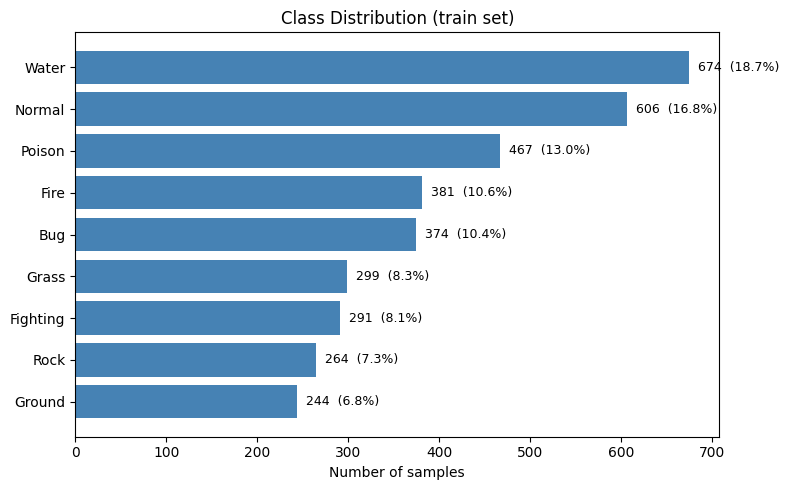

In [9]:
import src.datasets.eda_plots as eda_plots

fig = eda_plots.plot_class_distribution(df_full, out_path=TASK_OUT_DIR / "plots" / "plot_class_distribution.png")
plt.show()
plt.close(fig)


> **Result:**

> Water is the majority class with **674 images (18.7%)**;

> Ground is the minority with **244 images (6.8%)**.

> Imbalance ratio: **2.76×**.  

> This way, if we always predict Water we would get 18.7% accuracy but macro-F1 ≈ 0.021 — this is why we use macro-F1 as the metric, not accuracy.

> For the loss we use inverse-frequency class weighting in CrossEntropyLoss (Ground gets weight ≈1.64×, Rock ≈1.52×, Fighting ≈1.37× vs Water ≈0.59×).  




### Plot 2 — Sample Images per Class

4 random images per class (fixed seed — same grid on every run).

**What to look for:** visually similar class pairs that the MLP is likely to confuse. Note colour and texture similarities across classes (e.g. Bug/Grass both greenish; Fighting/Normal both humanoid). These pairs will show up as off-diagonal errors in the confusion matrix.


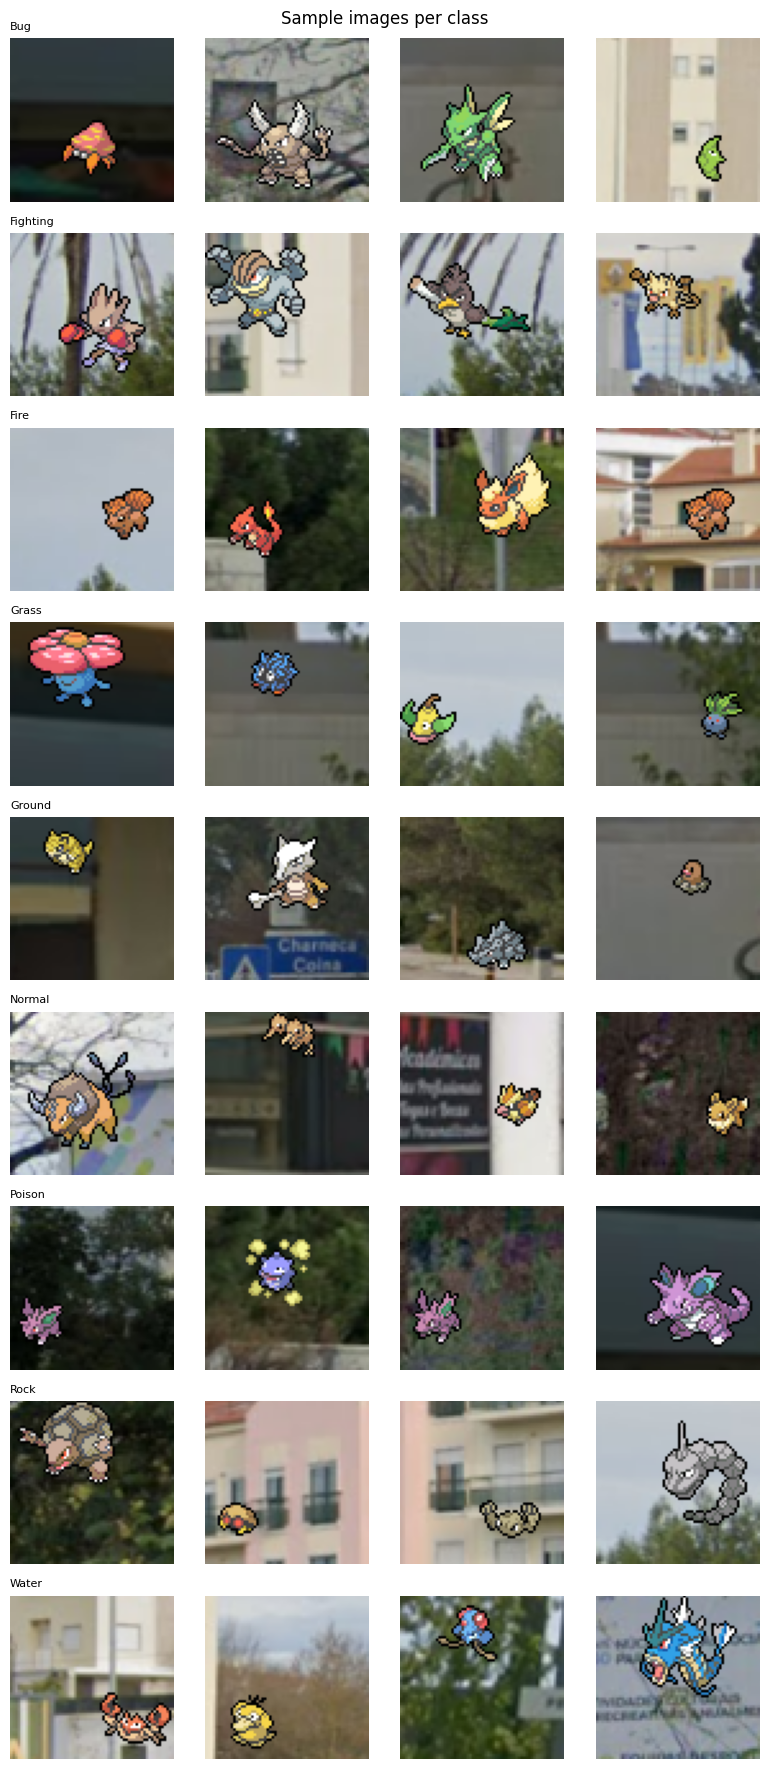

In [10]:
fig = eda_plots.plot_sample_images(TRAIN_DIR, df_full, n_per_class=4, out_path=TASK_OUT_DIR / "plots" / "plot_sample_images.png")
plt.show()
plt.close(fig)


> **Finding — Visual Similarity**

> Three high-risk confusion pairs stand out:  
> 1. **Bug ↔ Grass** — both dominated by green/yellow tones; the MLP flat vector sees near-identical colour histograms.

> 2. **Fighting ↔ Normal** — both humanoid silhouettes. Spatial layout differs (Fighting=muscular pose), but MLP ignores layout — only colour statistics remain, which largely overlap. Confirmed:

> 3. **Ground ↔ Rock** — both have brown/grey palettes with no distinctive hue.

> These are the primary off-diagonal hotspots in the confusion matrix.


### Plot 3 — Average Image per Class

Mean pixel value across all images in each class (after resizing to 64×64).

If we have a crisp average image means the class has consistent appearance (low intra-class variance → easier to classify).

A blurry/washed-out average means high intra-class variance → harder.

======== Example of Image Avg with a small sub set of images ==========


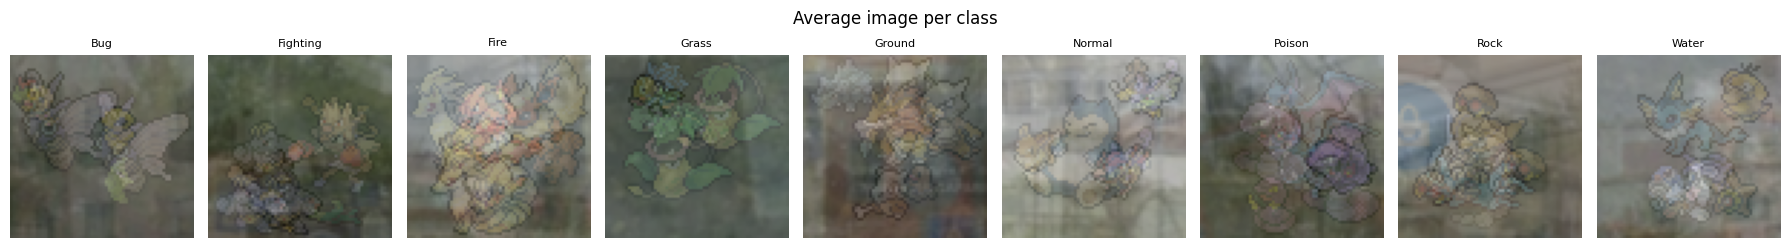

In [11]:

print ("======== Example of Image Avg with a small sub set of images ==========")

small_df = df_full.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
fig = eda_plots.plot_average_image_per_class(TRAIN_DIR, small_df, out_path=TASK_OUT_DIR / "plots" / "plot_average_image_per_class.png")
plt.show()
plt.close(fig)


======== Image Avg of all the data set images ==========


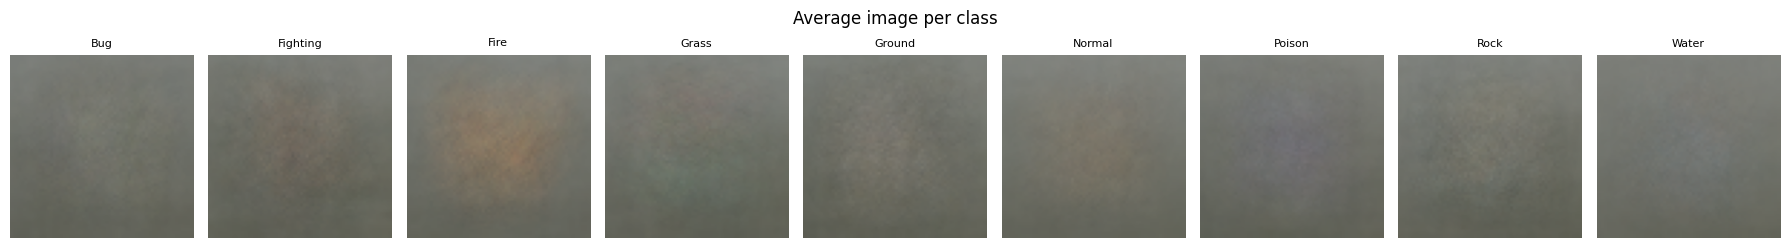

In [12]:

print ("======== Image Avg of all the data set images ==========")

fig = eda_plots.plot_average_image_per_class(TRAIN_DIR, df_full, out_path=TASK_OUT_DIR / "plots" / "plot_average_image_per_class.png")
plt.show()
plt.close(fig)


> **Results:** as we will see, image sharpness closelly correlate witht the resulting class scores.

> **Sharpest prototypes (low variance → easier):** Fire (warm orange centre, consistent palette → as we will see it indeed gets the best scores: F1=**0.480**, best) and Water (distinctly blue → F1=**0.358**, 2nd best).

> **Blurriest prototypes (high variance → harder):** Normal (washed-out grey — humanoids of all shapes, sizes, and colours → F1=0.199) and Fighting (similar diversity to Normal → F1=0.073, worst class). Ground's average is brownish but indistinct, overlapping Rock → F1=0.088.  



### Plot 4 — Per-Channel Pixel Statistics

Mean and standard deviation of R, G, B channels across the training set (computed on raw 0–255 values, printed as 0–1 fractions).

For transfer-learning models we might want to stick with their normalization values, example from ImageNet, but if we are training our own models and the values differ from ImageNet so we better use our data set values for mean/std.


Per-channel pixel stats (normalised 0-1):
  R: mean=0.4433, std=0.2567
  G: mean=0.4455, std=0.2464
  B: mean=0.4135, std=0.2655
ImageNet reference: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


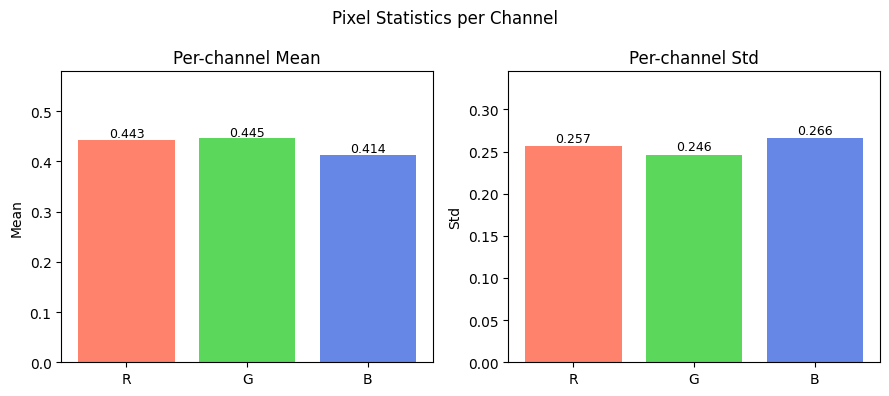

In [13]:
fig = eda_plots.plot_pixel_statistics(TRAIN_DIR, df_full, out_path=TASK_OUT_DIR / "plots" / "plot_pixel_statistics.png")
plt.show()
plt.close(fig)


> **Results:**

> This dataset is ~13–15% **brighter** than ImageNet (Pokémon sprites are pastel/bright) and slightly less variable. The difference per channel is < 0.15 — within acceptable range.

> **Conclusion:** we use ImageNet normalisation constants in our transforms. Dataset-specific constants would reduce normalisation error slightly but this way we get ready for better transfer learning models

### Plot 5 — Pixel Intensity Histogram

Histogram of pixel intensity values (0–255) for R, G, B channels sampled from the training set.

We should look for overall brightness range and channel imbalance. A histogram skewed toward high values → bright/pastel dataset. Nearly overlapping R/G/B histograms → low colour diversity. Either pattern suggests augmentation (colour jitter, flip) would help CNNs in Task 2.


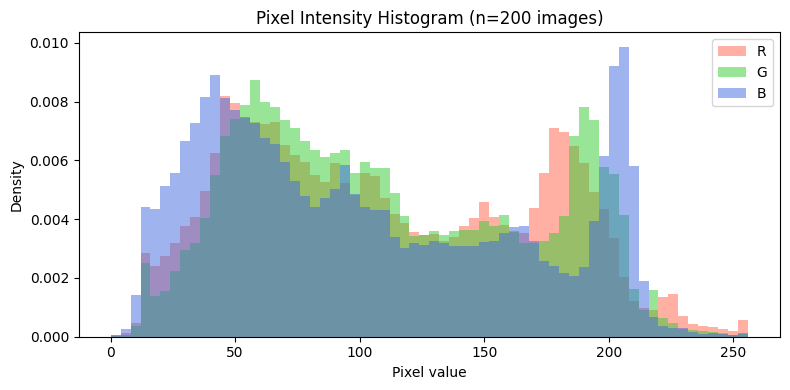

In [14]:
fig = eda_plots.plot_pixel_intensity_histogram(TRAIN_DIR, df_full, n_samples=200, out_path=TASK_OUT_DIR / "plots" / "plot_pixel_intensity_histogram.png")
plt.show()
plt.close(fig)


> **Rsults:**

> All three channels peak in the **180–220 range** — this is a bright/pastel dataset (Pokémon sprites are designed with vivid colours, not photographic statistics).  

> The three histograms largely overlap, indicating moderate colour diversity.

> For MLP (which sees pixels as independent scalars), this overlap means many classes share similar per-pixel intensity ranges — the discriminative signal comes from the combination of R/G/B, not individual channels.  

> For CNN (Task 2): this narrow intensity distribution means colour jitter augmentation would increase training diversity without distorting class-defining hues.


### Plot 6 — PCA → t-SNE Cluster Plot

Flatten each image to 12 288 features → PCA(50 dims) → t-SNE(2D) → scatter coloured by class.

Lets we ehave clear class clusters. If so, MLP has a chance. If everything is mixed together, no amount of FC layers will help, and so we'll need CNNs.

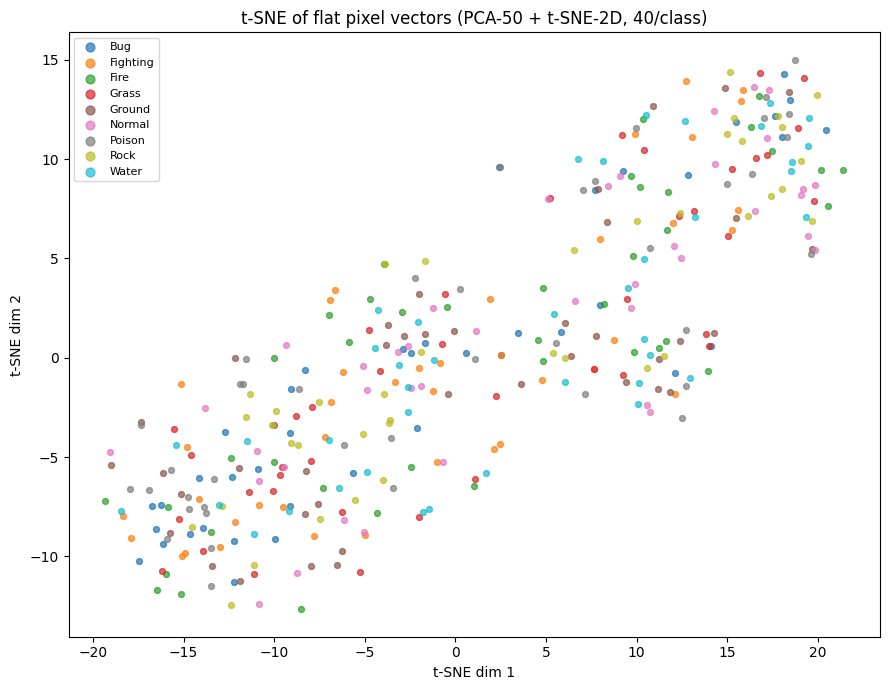

In [15]:
# ── t-SNE of flat pixel vectors ───────────────────────────────────────────────
# n_per_class=40 → 360 points total — fast enough even on CPU (~10s), meaningful enough to read
# EDA always on full dataset (df_full), never on the FAST_RUN subset
fig = eda_plots.plot_pca_tsne(
    TRAIN_DIR, df_full,
    n_per_class=6 if FAST_RUN else 40,
    out_path=TASK_OUT_DIR / "plots" / "plot_pca_tsne.png",
)
plt.show()
plt.close(fig)


> **Findings:**  

> **No clean clusters** — all 9 classes heavily overlap in t-SNE space. There is no region of 2D pixel-space that belongs exclusively to any class. We won't get good results with MLP. We need spatial structures and CNNs.

# Part 2 — Model Experiments

## Results Manager
> This global dictionary keeps track of the models we train along the notebook, so it is easy to keep track and compare all models we train.

> This global dictionary with models results can be initialized empty, or we can choose to upload some previous output zip folder that we have, so we update this global rsults manager dictionary with all the models we got in previous runs.

**Run this cell only if you want to upload the saved task_outputs.zip from google drive and restore the results_tracker dictionary with that data.**

In [27]:
from src.evaluation.persistence import restore_outputs

# Restore previous outputs from Drive/local backup.
# On Colab  : mounts Drive and reads from DRIVE_OUTPUTS_DIR (private mounted path).
# Locally   : downloads from DRIVE_FOLDER_URL (public shared folder).
# Skip entirely when USE_DRIVE=False — nothing to restore.

if USE_DRIVE:
    backup_dir = DRIVE_OUTPUTS_DIR if IN_COLAB else DRIVE_FOLDER_URL
    restore_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, backup_dir=backup_dir)
else:
    print("[restore] USE_DRIVE=False — skipping restore, starting fresh.")


[restore_outputs] restored 'task1_outputs.zip' -> task1


In [28]:
from src.evaluation.persistence import restore_tracker, ResultsTracker

# ResultsTracker = dict[str, ExperimentEntry]
# Each entry has these keys (see ExperimentEntry in persistence.py):
#   val_macro_f1 : float  — best val macro-F1 from the saved checkpoint
#   val_acc      : float  — val accuracy at that checkpoint
#   val_loss     : float  — val loss at that checkpoint (nan for ensembles)
#   total_epochs : int    — epochs actually run (< EPOCHS if early-stopped; 0 for ensembles)
#   train_time_s : float  — wall-clock training time in seconds (0.0 for ensembles)
#   history      : dict   — {"train_loss": [...], "val_loss": [...], "train_f1": [...], "val_f1": [...]}
#   child_models : list   — only present on ensemble entries; names of the averaged solo models
results_tracker: ResultsTracker = {}

results_json_path = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"


def _print_leaderboard(tracker: ResultsTracker) -> None:
    """Show all experiments sorted by val_macro_f1 descending as a styled DataFrame."""
    if not tracker:
        return
    rows = sorted(tracker.items(), key=lambda x: x[1]["val_macro_f1"], reverse=True)
    data = [
        {
            "rank":    rank,
            "name":    name,
            "val_F1":  round(m["val_macro_f1"], 4),
            "val_acc": round(m["val_acc"], 4),
            "epochs":  m["total_epochs"],
            "time(s)": round(m["train_time_s"], 1),
        }
        for rank, (name, m) in enumerate(rows, 1)
    ]
    df_lb = pd.DataFrame(data).set_index("rank")
    try:
        from IPython.display import display
        styled = (
            df_lb.style
            .background_gradient(subset=["val_F1"], cmap="RdYlGn", vmin=0.10, vmax=df_lb["val_F1"].max())
            .background_gradient(subset=["val_acc"], cmap="Blues", vmin=0.10, vmax=df_lb["val_acc"].max())
            .format({"val_F1": "{:.4f}", "val_acc": "{:.4f}", "time(s)": "{:.1f}"})
        )
        display(styled)
    except Exception:
        # terminal / non-Jupyter fallback
        print(df_lb.to_string())


print("-" * 50)
restore_tracker(results_json_path, results_tracker)
print("Current experiments in results_tracker:")
_print_leaderboard(results_tracker)


--------------------------------------------------
Restored 29 experiments from task1/outputs/results/task1_results.json
Current experiments in results_tracker:


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5


## Setup Experiments
These helper cells define the shared infrastructure used by every experiment:
- **`build_loaders(augment, use_sampler, grayscale, equalize)`** — wraps `get_train_val_loaders`, always uses `df` (which can be the subsampled FAST_RUN set)
- **`run_experiment(model, name, criterion, optimizer, scheduler, loaders)`** — full train loop, early stopping on `val_macro_f1`, checkpoint save, evaluate best, store in `results_tracker` and immediately upsert to `task1_results.json`

Each experiment cell is then just 4–5 lines: instantiate model, criterion, optimizer, scheduler → call `run_experiment`.


In [29]:

# ── Shared imports for all experiment cells ───────────────────────────────────
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.dataset import (
    PokemonDataset, compute_class_weights,
    get_base_transforms, get_gray_transforms, get_train_val_loaders,
)
from src.models.mlp import MLP, VanillaMLP, VanillaMLP_v2, NarrowMLP, BottleneckMLP, WiderMLP, DeepMLP
from src.training.train import train_one_epoch, evaluate
from src.training.early_stopping import EarlyStopping
from src.evaluation.metrics import classification_report_str
from src.evaluation.plots import plot_history, plot_confusion_matrix
from src.evaluation.persistence import save_experiment_result, save_all_results, save_outputs
from src.evaluation.submission import generate_submission_from_preds, validate_submission

import time

# build class weights from the run's df (correct proportions even for FAST_RUN)
label_to_idx     = {cls: i for i, cls in enumerate(CLASSES)}
_all_train_labels = [label_to_idx[lbl] for lbl in df["label"]]
class_weights    = compute_class_weights(_all_train_labels).to(device)

# test loader is always the full test set — not touched until submission
test_ds     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE), csv_path=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# single path for incremental per-experiment saves and final save_all_results
RESULTS_PATH = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"
SUB_PATH     = TASK_OUT_DIR / "results" / f"submission_{TASK_NAME}.csv"

print(f"Test images  : {len(test_ds)}")
print(f"Class weights: { {cls: round(class_weights[i].item(), 3) for i, cls in enumerate(CLASSES)} }")


# ── Helper: build_loaders ─────────────────────────────────────────────────────
def build_loaders(augment: bool = False, use_sampler: bool = False,
                  grayscale: bool = False, equalize: bool = False):
    """Return (train_loader, val_loader) for the current df and hyperparams.
    grayscale=True → (1,H,W) tensors, input_dim=4096. equalize=True → histogram stretch before gray."""
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
        augment=augment, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
        grayscale=grayscale, equalize=equalize,
    )


# pre-build the two standard loader pairs used by all Part 2 experiments
loaders_base    = build_loaders(augment=False, use_sampler=False)
loaders_sampler = build_loaders(augment=False, use_sampler=True)


# ── Helper: _make_test_loader ─────────────────────────────────────────────────
def _make_test_loader(stem: str) -> DataLoader:
    """Return a test DataLoader with the correct transform for the given experiment stem.
    Gray experiments need grayscale transforms; all others use the standard RGB transform."""
    if stem.endswith("_gray_eq"):
        t = get_gray_transforms(IMG_SIZE, equalize=True)
    elif stem.endswith("_gray"):
        t = get_gray_transforms(IMG_SIZE, equalize=False)
    else:
        return test_loader   # reuse the global RGB test loader
    ds = PokemonDataset(TEST_DIR, t, csv_path=None)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# ── Helper: _is_new_overall_best ─────────────────────────────────────────────
def _is_new_overall_best(name: str, f1: float) -> bool:
    """True if this experiment (solo or ensemble) beats every other entry in results_tracker.
    Compares against all existing entries so the CSV is only updated when we truly have a new top."""
    other_f1s = [v["val_macro_f1"] for k, v in results_tracker.items() if k != name]
    return f1 > max(other_f1s, default=-1)


# ── Helper: run_experiment ────────────────────────────────────────────────────
def run_experiment(model, name: str, criterion, optimizer, scheduler, loaders) -> tuple:
    """
    Train model up to EPOCHS with early stopping on val macro-F1.
    Saves best checkpoint to {TASK_OUT_DIR}/checkpoints/<name>.pth.
    Upserts this experiment into {TASK_NAME}_results.json after each run.
    If this experiment is the new overall best (beats solo models AND ensembles),
    auto-regenerates submission_{TASK_NAME}.csv.
    Returns (model_with_best_weights, history_dict).
    """
    train_loader, val_loader = loaders
    ckpt_path = str(TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
    stopper   = EarlyStopping(patience=PATIENCE, checkpoint_path=ckpt_path)
    history   = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    t0        = time.time()

    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  Model params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        ep_t0         = time.time()
        train_loss    = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_metrics = evaluate(model, train_loader, criterion, device)
        val_metrics   = evaluate(model, val_loader,   criterion, device)
        elapsed       = time.time() - ep_t0
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_f1"].append(train_metrics["macro_f1"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}  val_f1={val_metrics['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

        # negate val_f1 because EarlyStopping minimises — this saves the peak-F1 checkpoint
        stopper(-val_metrics["macro_f1"], model)
        if stopper.stop:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE}, metric: val_macro_f1).")
            break

    total_time = time.time() - t0

    # reload best checkpoint and run a final clean evaluation
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    best = evaluate(model, val_loader, criterion, device)

    entry = {
        "val_macro_f1": round(best["macro_f1"], 4),
        "val_acc":      round(best["acc"], 4),
        "val_loss":     round(best["loss"], 4),
        "total_epochs": len(history["train_loss"]),
        "train_time_s": round(total_time, 1),
        "history":      history,
    }
    results_tracker[name] = entry

    print(f"\n  Best checkpoint: val_loss={best['loss']:.4f}  val_macro_f1={best['macro_f1']:.4f}")
    print(f"  Total time: {total_time:.1f}s ({total_time/len(history['train_loss']):.1f}s/epoch)")
    _print_leaderboard(results_tracker)

    # save this experiment's result to disk immediately — no data lost if Colab disconnects
    save_experiment_result(name, entry, RESULTS_PATH)

    # auto-update submission if this solo model beats everyone (solo + ensemble)
    if _is_new_overall_best(name, entry["val_macro_f1"]):
        print(f"\n  New overall best — regenerating submission CSV...")
        _tl = _make_test_loader(name)
        test_preds = []
        model.eval()
        with torch.no_grad():
            for imgs, _ in _tl:
                imgs = imgs.to(device)
                test_preds.extend(model(imgs).argmax(dim=1).cpu().tolist())
        generate_submission_from_preds(_tl, test_preds, CLASSES, SUB_PATH)
        validate_submission(SUB_PATH)
        print(f"  Submission updated -> {SUB_PATH}")

    if SAVE_IN_EACH_RUN:
        save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)

    return model, history


Test images  : 900
Class weights: {'Bug': 1.07, 'Fighting': 1.375, 'Fire': 1.05, 'Grass': 1.338, 'Ground': 1.639, 'Normal': 0.66, 'Poison': 0.857, 'Rock': 1.515, 'Water': 0.593}


## Experiments Plan & Registry

| ID | Name | Model | Criterion (~loss function) | Optimizer | Purpose |
|---|---|---|---|---|---|
| A | vanilla | VanillaMLP (128→64), no BN, no Dropout | CrossEntropy | Adam lr=1e-3 | True bare baseline — no regularisation at all |
| B | mlp_base | MLP (512→256→128), BN, Dropout(0.4) | CE + class weights | Adam lr=1e-3 | First Colab run result (~0.193) |
| C | ls01_drop03 | MLP, Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam lr=1e-3 | Softer targets + lighter dropout |
| D | wd1e4 | MLP, Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | L2 reg on top of C |
| E | sampler | MLP, Dropout(0.3) | CE + label_smoothing=0.1 (sampler used instead of class-weights) | Adam lr=1e-3 | WeightedRandomSampler replaces class weights |
| F | narrow | NarrowMLP (256→128→64→32), Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | Fewer params per layer — less overfit? |
| G | bottleneck | BottleneckMLP (512→1024→256→128), Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | Wide middle captures more combinations? |
| H | vanilla_v2 | VanillaMLP_v2 (256→128), no BN, no Dropout | CrossEntropy | Adam lr=1e-3 | A won → more capacity + no reg helps? |
| I | v2_rock_weights | VanillaMLP_v2, no Dropout | CE with targeted class weights (Rock×3, Ground×2) | Adam lr=1e-3 | Targeted upweighting of worst 2 classes |
| J | mlp_drop02 | MLP, Dropout(0.2) | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | Sweet spot between 0.0 (A) and 0.3 (D)? |
| K | v2_wd1e5 | VanillaMLP_v2, no Dropout | CrossEntropy | Adam lr=1e-3, WD=1e-5 | Infinitesimal L2 — tests regularisation boundary |
| L | wider_ls | WiderMLP (1024→512→256), LS=0.1 | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | Wider arch; val_macro_f1=0.2196 — wider hurts (more overfitting) |
| M | c_sampler | MLP (C arch) + WeightedSampler | CE + label_smoothing=0.1 (sampler replaces class-weights) | Adam lr=1e-3 | Sampler on top of C — ~same as E (val_macro_f1=0.2361) |
| N | cosine_lr | MLP (C arch) + CosineAnnealing | CE + weights + label_smoothing=0.1 | Adam lr=1e-3 + CosineAnnealingLR | Cosine schedule, no improvement (val_macro_f1=0.2251) |
| O | c_sampler_cw | MLP (C arch) + WeightedSampler + ClassWeights | CE + label_smoothing=0.1 (sampler + class-weights together) | Adam lr=1e-3 | Sampler + class-weights double-compensate — hurts (val_macro_f1=0.1920) |
| P | drop015_ls | MLP (C arch), Dropout=0.15, LS=0.1 | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | Less dropout than C; marginal effect (val_macro_f1=0.2171) |
| Q | wider_sampler | WiderMLP + WeightedSampler | CE + label_smoothing=0.1 (sampler used) | Adam lr=1e-3, WD=1e-4 | Wider + sampler: higher capacity + sampler helps (val_macro_f1=0.2374) |
| R | ls015_drop03 | MLP, Dropout=0.3, LS=0.15, CW | CE + weights + label_smoothing=0.15 | Adam lr=1e-3, WD=1e-4 | Best solo — LS=0.15 > LS=0.10 (val_macro_f1=0.2396) |
| S | deep_ls | DeepMLP (4-layer funnel), LS=0.1 | CE + weights + label_smoothing=0.1 | Adam lr=1e-3, WD=1e-4 | Deeper hurts with small dataset (val_macro_f1=0.1905) |



**rationale:**

> regularisation changes (C–E)

> architecture changes (F–G)

> capacity ablation (H–K)



**what not tried and why**

> More hidden layers / wider layers: we already have overfitting considering the low amount of training data we have. We have train_f1≈0.55 vs val_f1≈0.19, so adding more parameters to do model will make overfitting worse.

> More epochs: we use epochs = 30 and most of models already stop early. And we need too manage ou computing time availability.

> Grid search: a 5×5 grid over {dropout, weight_decay, label_smoothing, LR, architecture} = 25 runs × ~80s ≈ 33 min. We should try a more targeted approach guided by the previous result, more than a blind sweep.


**Preprocessing Pipeline**

> Every image passes through a transform pipeline before reaching the model, implemented in `src/datasets/dataset.py` and selected by `get_train_val_loaders`. The default RGB pipeline is:

```
Raw PNG  →  Resize(64, 64)  →  ToTensor()  →  Normalize(mean, std)
```

| Step | What/Why|
|---|---|
| `Resize(64, 64)` | Bicubic-downsample each image to 64×64 px so we'll have a fixed-size vector to the MLP |
| `ToTensor()` | Converts PIL image uint8 (0–255) to float32 tensors [0, 1] |
| `Normalize(mean, std)` | Per-channel: `pixel = (pixel - mean) / std`, to center around zero and help faster convergence |

> We use ImageNet means `[0.485, 0.456, 0.406]` and stds `[0.229, 0.224, 0.225]`, which are pre-computed over 1.2M images and are a solid approximation for natural images even without fine-tuning, so these values might best fit pre-trained models when we do transfer-learning, and because when we compare this mean/stds from ImageNet to our train-split dataset they are close values, so it is ok for our "learn from scratch models".

**What we don't do**:

> No histogram equalisation in the default pipeline, which would redistribute pixel intensities, and so increase contrast. This would be good to better learn "countours and lines", but would "vanish" edge colors like orange, red, purple, blue, which might be important to distinguish between classes like Fire = orange, Water = blue, Poison = purple.

In [30]:
# Registry: one entry per experiment stem.
# "model"      — zero-arg factory for the RGB version (in_channels=3).
# "model_gray" — zero-arg factory for the grayscale version (in_channels=1).
# "criterion"  — zero-arg factory; must match what was used during training.
#
# Grayscale (_gray, _gray_eq) and augmented (_augmented) variants are registered
# dynamically in Part 3 cells — their stems depend on best_name at runtime.
model_registry = {
    # ── RGB experiments ────────────────────────────────────────────────────────
    "A_vanilla":         {"model":      lambda: VanillaMLP(img_size=IMG_SIZE),
                          "model_gray": lambda: VanillaMLP(img_size=IMG_SIZE, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss()},
    "B_mlp_base":        {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.4),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.4, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights)},
    "C_ls01_drop03":     {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "D_wd1e4":           {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "E_sampler":         {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(label_smoothing=0.1)},
    "F_narrow":          {"model":      lambda: NarrowMLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: NarrowMLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "G_bottleneck":      {"model":      lambda: BottleneckMLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: BottleneckMLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "H_vanilla_v2":      {"model":      lambda: VanillaMLP_v2(img_size=IMG_SIZE),
                          "model_gray": lambda: VanillaMLP_v2(img_size=IMG_SIZE, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss()},
    "I_v2_rock_weights": {"model":      lambda: VanillaMLP_v2(img_size=IMG_SIZE),
                          "model_gray": lambda: VanillaMLP_v2(img_size=IMG_SIZE, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(
                              weight=torch.tensor([1.,1.,1.,2.,1.,1.,3.,1.,1.], device=device))},
    "J_mlp_drop02":      {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.2),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.2, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "K_v2_wd1e5":        {"model":      lambda: VanillaMLP_v2(img_size=IMG_SIZE),
                          "model_gray": lambda: VanillaMLP_v2(img_size=IMG_SIZE, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss()},
    # ── Extension experiments L-N (uncommented after first Colab run) ──────────
    "L_wider_ls":        {"model":      lambda: WiderMLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: WiderMLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "M_c_sampler":       {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(label_smoothing=0.1)},
    "N_cosine_lr":       {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    # ── Extension experiments O-S (5 new runs around C and M) ─────────────────
    "O_c_sampler_cw":    {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "P_drop015_ls":      {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.15),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.15, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},
    "Q_wider_sampler":   {"model":      lambda: WiderMLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: WiderMLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(label_smoothing=0.1)},
    "R_ls015_drop03":    {"model":      lambda: MLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)},
    "S_deep_ls":         {"model":      lambda: DeepMLP(img_size=IMG_SIZE, dropout=0.3),
                          "model_gray": lambda: DeepMLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1),
                          "criterion":  lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)},

    # ── Grayscale and augmented variants — registered dynamically in Part 3 ───
    # "{best_name}_gray"       added after Part 3.1 Gray experiment
    # "{best_name}_gray_eq"    added after Part 3.1 Gray+Eq experiment
    # "{best_name}_augmented"  added after Part 3.2 augmentation experiment
}


### A: Vanilla Baseline
###### ──────────────────────────────────────────

```
[12288] → [128] → [64] → [9]
            ReLU    ReLU   (logits)
```

 > Tiny 2-layer MLP, no BN, no Dropout, no class weights — a true baseline.

 > Architecture: Flatten -> FC(12288->128) -> ReLU -> FC(128->64) -> ReLU -> FC(64->9)

 > Uses VanillaMLP from src.models.mlp (imported in shared cell above).

 > Purpose: have a basic model to confirm everything works and from which we can start improving

**logits vs softmax**
> This model (and all following ones) outputs raw logits — no softmax applied. `CrossEntropyLoss` fuses `log_softmax + NLLLoss` internally, so feeding it raw logits is both correct and numerically more stable. At inference, `argmax(logits) == argmax(softmax(logits))` always, so softmax adds no value there either. The one place we do apply softmax explicitly is in `ensemble.py`: before averaging the outputs of two models we call `F.softmax()` on each, because averaging raw logits from different models is wrong — their scales differ and the sum would not be a valid probability distribution.

In [ ]:

# This instantiates our model and moves it to device (gpu/cpu)
model_A     = VanillaMLP(img_size=IMG_SIZE).to(device)

# This defines the loss functin
criterion_A = nn.CrossEntropyLoss()   # no class weights — true bare baseline

# This defines the optimizer for gradient descent
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR)

# This defines a learning rate scheduler to dynamically adjust the LR during training
scheduler_A = torch.optim.lr_scheduler.StepLR(optimizer_A, step_size=5, gamma=0.5)

model_A, history_A = run_experiment(model_A, "A_vanilla", criterion_A, optimizer_A, scheduler_A, loaders_base)



  Experiment: A_vanilla
  Model params: 1,581,833
  Epoch 01/30 | train_loss=2.3818  train_f1=0.1984 | val_loss=2.3675  val_f1=0.1404 | 4.7s
  Epoch 02/30 | train_loss=2.0371  train_f1=0.3020 | val_loss=2.3129  val_f1=0.1393 | 5.3s
  Epoch 03/30 | train_loss=1.8101  train_f1=0.3808 | val_loss=2.2294  val_f1=0.1661 | 4.2s
  Epoch 04/30 | train_loss=1.6731  train_f1=0.3893 | val_loss=2.4412  val_f1=0.1387 | 4.0s
  Epoch 05/30 | train_loss=1.5533  train_f1=0.4717 | val_loss=2.4091  val_f1=0.1764 | 5.3s
  Epoch 06/30 | train_loss=1.2446  train_f1=0.6632 | val_loss=2.2002  val_f1=0.2104 | 4.1s
  Epoch 07/30 | train_loss=1.0461  train_f1=0.7604 | val_loss=2.2325  val_f1=0.1903 | 4.1s
  Epoch 08/30 | train_loss=0.9067  train_f1=0.7737 | val_loss=2.4029  val_f1=0.2003 | 5.4s
  Epoch 09/30 | train_loss=0.8037  train_f1=0.8220 | val_loss=2.3912  val_f1=0.2179 | 4.3s
  Epoch 10/30 | train_loss=0.6867  train_f1=0.8490 | val_loss=2.5756  val_f1=0.1890 | 4.7s
  Epoch 11/30 | train_loss=0.5089  trai

### B: MLP Baseline
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.4)  D(0.4)  D(0.4)
```

 > 3 FC Layers: (FC → BN → ReLU → Dropout(0.4) → weighted CrossEntropy).

 > Flatten 64×64×3 → 12 288

 > 3 FC to add depth/capacity, but 3 is enough;

 > Width 512 → 256 → 128 to funel and force compression;

 > Batch Norm after every FC to stabilise gradients with large flat input

 > Dropout (tested 0.0–0.4) for regularisation for large param count on ~2880 train images

 > Output - no softmax: `CrossEntropyLoss` applies log-softmax internally

> Loss - CrossEntropyLoss(weight=class_weights) to correct the imbalance

> Optimiser (Adam lr=1e-3, adaptive LR) - robust default

> Scheduler (StepLR(step_size=5, γ=0.5)) - halves LR every 5 epochs

> Early stopping (patience=7) - a bit bigger patience to prevent premature stopping because we are using val_macro_f1, which is noisier than val_loss (80 samples/class → 1 error = ±1.2% swing)

In [ ]:
model_B     = MLP(img_size=IMG_SIZE, dropout=0.4).to(device)
criterion_B = nn.CrossEntropyLoss(weight=class_weights)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=LR)
scheduler_B = torch.optim.lr_scheduler.StepLR(optimizer_B, step_size=5, gamma=0.5)

model_B, history_B = run_experiment(model_B, "B_mlp_base", criterion_B, optimizer_B, scheduler_B, loaders_base)



  Experiment: B_mlp_base
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.2878  train_f1=0.1125 | val_loss=2.2164  val_f1=0.0922 | 4.1s
  Epoch 02/30 | train_loss=2.2587  train_f1=0.1141 | val_loss=2.2024  val_f1=0.0871 | 4.0s
  Epoch 03/30 | train_loss=2.2184  train_f1=0.1260 | val_loss=2.1947  val_f1=0.0807 | 5.3s
  Epoch 04/30 | train_loss=2.2227  train_f1=0.1264 | val_loss=2.1951  val_f1=0.0826 | 4.1s
  Epoch 05/30 | train_loss=2.2008  train_f1=0.1703 | val_loss=2.1953  val_f1=0.1004 | 4.8s
  Epoch 06/30 | train_loss=2.1777  train_f1=0.1981 | val_loss=2.1763  val_f1=0.1282 | 5.2s
  Epoch 07/30 | train_loss=2.1474  train_f1=0.2450 | val_loss=2.1590  val_f1=0.1374 | 4.0s
  Epoch 08/30 | train_loss=2.0903  train_f1=0.2240 | val_loss=2.1550  val_f1=0.1235 | 4.4s
  Epoch 09/30 | train_loss=2.0480  train_f1=0.2980 | val_loss=2.1141  val_f1=0.1679 | 4.8s
  Epoch 10/30 | train_loss=1.9794  train_f1=0.3444 | val_loss=2.0970  val_f1=0.1919 | 4.0s
  Epoch 11/30 | train_loss=1.9183  tra

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### C: Dropout(0.3) + label_smoothing=0.1
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
```

> slightly less regularisation (dropout 0.4→0.3).

> softer targets (label_smoothing=0.1) to distribute  0.1 of the probability mass to wrong classes, to prevent the model from trying to be overconfident — known to help imbalanced multi-class problems. So instead of trying to say that a pokemon is water type with 100% confidence: `[1, 0, 0, 0, 0, 0, 0, 0, 0]` it becomes `[0.9, 0.0125, 0.0125, 0.0125, 0.0125, 0.0125, 0.0125, 0.0125, 0.0125]`, and so it improves generalization.

In [ ]:
model_C     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_C = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_C = torch.optim.Adam(model_C.parameters(), lr=LR)
scheduler_C = torch.optim.lr_scheduler.StepLR(optimizer_C, step_size=5, gamma=0.5)

model_C, history_C = run_experiment(model_C, "C_ls01_drop03", criterion_C, optimizer_C, scheduler_C, loaders_base)



  Experiment: C_ls01_drop03
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.2926  train_f1=0.0912 | val_loss=2.2553  val_f1=0.0738 | 4.1s
  Epoch 02/50 | train_loss=2.2674  train_f1=0.1169 | val_loss=2.2350  val_f1=0.0770 | 5.1s
  Epoch 03/50 | train_loss=2.2385  train_f1=0.1653 | val_loss=2.2097  val_f1=0.1335 | 4.1s
  Epoch 04/50 | train_loss=2.1923  train_f1=0.1856 | val_loss=2.1677  val_f1=0.1532 | 4.5s
  Epoch 05/50 | train_loss=2.1344  train_f1=0.2010 | val_loss=2.1576  val_f1=0.1350 | 4.8s
  Epoch 06/50 | train_loss=2.0953  train_f1=0.2136 | val_loss=2.1784  val_f1=0.1346 | 4.1s
  Epoch 07/50 | train_loss=2.0424  train_f1=0.3344 | val_loss=2.1199  val_f1=0.1788 | 5.0s
  Epoch 08/50 | train_loss=1.9911  train_f1=0.3713 | val_loss=2.1111  val_f1=0.1957 | 4.3s
  Epoch 09/50 | train_loss=1.9523  train_f1=0.3854 | val_loss=2.1452  val_f1=0.1853 | 4.1s
  Epoch 10/50 | train_loss=1.8816  train_f1=0.4531 | val_loss=2.1241  val_f1=0.2054 | 5.2s
  Epoch 11/50 | train_loss=1.7919  

### D: + weight_decay=1e-4
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
            + Adam WD=1e-4
```

> Adds L2 regularisation to Experiment C. L2 penalises large weights, which should help reduce the train/val gap further.

In [ ]:
model_D     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_D = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_D = torch.optim.Adam(model_D.parameters(), lr=LR, weight_decay=1e-4)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=5, gamma=0.5)

model_D, history_D = run_experiment(model_D, "D_wd1e4", criterion_D, optimizer_D, scheduler_D, loaders_base)



  Experiment: D_wd1e4
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.3055  train_f1=0.0902 | val_loss=2.2323  val_f1=0.0577 | 4.3s
  Epoch 02/50 | train_loss=2.2422  train_f1=0.1602 | val_loss=2.2289  val_f1=0.1026 | 5.5s
  Epoch 03/50 | train_loss=2.2258  train_f1=0.1819 | val_loss=2.2105  val_f1=0.1364 | 4.3s
  Epoch 04/50 | train_loss=2.1865  train_f1=0.1755 | val_loss=2.2073  val_f1=0.1156 | 4.2s
  Epoch 05/50 | train_loss=2.1193  train_f1=0.2232 | val_loss=2.1605  val_f1=0.1343 | 5.5s
  Epoch 06/50 | train_loss=2.0765  train_f1=0.3044 | val_loss=2.1429  val_f1=0.1860 | 4.2s
  Epoch 07/50 | train_loss=2.0401  train_f1=0.3223 | val_loss=2.1487  val_f1=0.1702 | 4.3s
  Epoch 08/50 | train_loss=1.9868  train_f1=0.3777 | val_loss=2.1262  val_f1=0.1757 | 5.4s
  Epoch 09/50 | train_loss=1.9285  train_f1=0.3445 | val_loss=2.1475  val_f1=0.1517 | 4.2s
  Epoch 10/50 | train_loss=1.8650  train_f1=0.4206 | val_loss=2.1382  val_f1=0.1819 | 4.8s
  Epoch 11/50 | train_loss=1.7570  train_

### E: WeightedRandomSampler
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
            + WeightedRandomSampler (no loss class-weights)
```

> We use the `build_loaders(..., use_sampler=True)` so the loader will oversample minority classes. It replaces the class weights in the loss function - we don't use both to not overcorrect the class imbalance.

> we keep label_smoothing from Experiment C, which was independently helpful.

In [ ]:
model_E     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_E = nn.CrossEntropyLoss(label_smoothing=0.1)  # no class weights — sampler handles it
optimizer_E = torch.optim.Adam(model_E.parameters(), lr=LR, weight_decay=1e-4)
scheduler_E = torch.optim.lr_scheduler.StepLR(optimizer_E, step_size=5, gamma=0.5)

model_E, history_E = run_experiment(model_E, "E_sampler", criterion_E, optimizer_E, scheduler_E, loaders_sampler)



  Experiment: E_sampler
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.2514  train_f1=0.1137 | val_loss=2.2205  val_f1=0.0819 | 4.1s
  Epoch 02/50 | train_loss=2.2079  train_f1=0.1707 | val_loss=2.2001  val_f1=0.1134 | 5.4s
  Epoch 03/50 | train_loss=2.1714  train_f1=0.1682 | val_loss=2.2045  val_f1=0.0944 | 4.2s
  Epoch 04/50 | train_loss=2.1005  train_f1=0.2398 | val_loss=2.1526  val_f1=0.1377 | 4.2s
  Epoch 05/50 | train_loss=2.0426  train_f1=0.3282 | val_loss=2.0961  val_f1=0.1811 | 5.6s
  Epoch 06/50 | train_loss=1.9834  train_f1=0.3514 | val_loss=2.1344  val_f1=0.1683 | 4.2s
  Epoch 07/50 | train_loss=1.8834  train_f1=0.4175 | val_loss=2.1077  val_f1=0.1917 | 4.2s
  Epoch 08/50 | train_loss=1.7961  train_f1=0.4695 | val_loss=2.1056  val_f1=0.1940 | 5.6s
  Epoch 09/50 | train_loss=1.7286  train_f1=0.5128 | val_loss=2.1177  val_f1=0.1946 | 4.3s
  Epoch 10/50 | train_loss=1.6619  train_f1=0.5312 | val_loss=2.1543  val_f1=0.1704 | 5.1s
  Epoch 11/50 | train_loss=1.5325  trai

### F: Narrow + Deep MLP
###### ──────────────────────────────────────────

```
[12288] → [256] → [128] → [64] → [32] → [9]
            ReLU    ReLU    ReLU   ReLU   (logits)
            BN      BN      BN     BN
            D(0.3)  D(0.3)  D(0.3) D(0.3)
```

> More deep arhcitecture with 4 hidden layers and max width 256:

> `input -> 256 -> 128 -> 64 -> 32 -> 9`

> We're building on the hypothesis that fewer params per layer → less overfit on 2880 train images.

> We keep the best regularisation combo from D: dropout=0.3 + label_smoothing + weight_decay.

In [ ]:
model_F     = NarrowMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_F = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_F = torch.optim.Adam(model_F.parameters(), lr=LR, weight_decay=1e-4)
scheduler_F = torch.optim.lr_scheduler.StepLR(optimizer_F, step_size=5, gamma=0.5)

model_F, history_F = run_experiment(model_F, "F_narrow", criterion_F, optimizer_F, scheduler_F, loaders_base)



  Experiment: F_narrow
  Model params: 3,190,473
  Epoch 01/50 | train_loss=2.2993  train_f1=0.1020 | val_loss=2.2297  val_f1=0.0793 | 4.2s
  Epoch 02/50 | train_loss=2.2665  train_f1=0.1231 | val_loss=2.2268  val_f1=0.0864 | 5.8s
  Epoch 03/50 | train_loss=2.2483  train_f1=0.1199 | val_loss=2.2226  val_f1=0.0957 | 4.8s
  Epoch 04/50 | train_loss=2.2374  train_f1=0.1363 | val_loss=2.2258  val_f1=0.0946 | 4.2s
  Epoch 05/50 | train_loss=2.2372  train_f1=0.1337 | val_loss=2.2229  val_f1=0.0937 | 5.4s
  Epoch 06/50 | train_loss=2.2181  train_f1=0.1759 | val_loss=2.2145  val_f1=0.1075 | 4.3s
  Epoch 07/50 | train_loss=2.2065  train_f1=0.1774 | val_loss=2.2046  val_f1=0.1219 | 4.2s
  Epoch 08/50 | train_loss=2.1891  train_f1=0.1890 | val_loss=2.1826  val_f1=0.1424 | 5.4s
  Epoch 09/50 | train_loss=2.1683  train_f1=0.1998 | val_loss=2.1673  val_f1=0.1618 | 4.2s
  Epoch 10/50 | train_loss=2.1427  train_f1=0.1977 | val_loss=2.1737  val_f1=0.1317 | 4.2s
  Epoch 11/50 | train_loss=2.1380  train

### G: Bottleneck MLP
###### ──────────────────────────────────────────

```
[12288] → [512] → [1024] → [256] → [128] → [9]
            ReLU    ReLU     ReLU    ReLU   (logits)
            BN      BN       BN      BN
            D(0.3)  D(0.3)   D(0.3)  D(0.3)
                    ↑ expand          ↑ compress
```

> Architecture: compress and expand again:

> `input (12.288) -> 512 -> 1024 -> 256 -> 128 -> 9`

> Hypothesis: the wide middle (1024 units) captures cross-pixel combinations before compressing down — the bottleneck pattern.

> Same regularisation as D/F — isolating the architecture change.

In [ ]:

model_G     = BottleneckMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_G = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_G = torch.optim.Adam(model_G.parameters(), lr=LR, weight_decay=1e-4)
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=5, gamma=0.5)

model_G, history_G = run_experiment(model_G, "G_bottleneck", criterion_G, optimizer_G, scheduler_G, loaders_base)



  Experiment: G_bottleneck
  Model params: 7,117,577
  Epoch 01/50 | train_loss=2.3045  train_f1=0.1034 | val_loss=2.2515  val_f1=0.0750 | 4.3s
  Epoch 02/50 | train_loss=2.2696  train_f1=0.0996 | val_loss=2.2289  val_f1=0.0735 | 4.2s
  Epoch 03/50 | train_loss=2.2569  train_f1=0.1293 | val_loss=2.2405  val_f1=0.1006 | 5.4s
  Epoch 04/50 | train_loss=2.2370  train_f1=0.1360 | val_loss=2.2298  val_f1=0.0963 | 4.2s
  Epoch 05/50 | train_loss=2.2202  train_f1=0.1703 | val_loss=2.1969  val_f1=0.1190 | 4.4s
  Epoch 06/50 | train_loss=2.1462  train_f1=0.2078 | val_loss=2.1721  val_f1=0.1513 | 5.2s
  Epoch 07/50 | train_loss=2.1235  train_f1=0.2270 | val_loss=2.1597  val_f1=0.1408 | 4.2s
  Epoch 08/50 | train_loss=2.0880  train_f1=0.2428 | val_loss=2.1597  val_f1=0.1375 | 5.3s
  Epoch 09/50 | train_loss=2.0522  train_f1=0.2788 | val_loss=2.1725  val_f1=0.1484 | 4.5s
  Epoch 10/50 | train_loss=2.0330  train_f1=0.2891 | val_loss=2.1568  val_f1=0.1448 | 4.3s
  Epoch 11/50 | train_loss=1.9441  t

### H: VanillaMLP_v2 (wider, no regularisation)
###### ──────────────────────────────────────────

```
[12288] → [256] → [128] → [9]
            ReLU    ReLU   (logits)
```

> Architecture:

> `12288 -> 256 -> 128 -> 9`

> Hypothesis: VanillaMLP (A) won on the first runs over all regularised models, suggesting the problem is NOT overfitting from width but from regularisation suppressing signal.

> VanillaMLP_v2 doubles the first layer (128->256) to test if more capacity without regularisation continues to help. So `A's ~1.58M params` to this one `~3.18M params`.

In [ ]:
model_H     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
criterion_H = nn.CrossEntropyLoss()   # no class weights — keep same bare baseline setup as A
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=5, gamma=0.5)

model_H, history_H = run_experiment(model_H, "H_vanilla_v2", criterion_H, optimizer_H, scheduler_H, loaders_base)



  Experiment: H_vanilla_v2
  Model params: 3,180,041
  Epoch 01/50 | train_loss=2.6458  train_f1=0.2435 | val_loss=2.2993  val_f1=0.1581 | 4.2s
  Epoch 02/50 | train_loss=2.0626  train_f1=0.2941 | val_loss=2.2634  val_f1=0.1384 | 4.2s
  Epoch 03/50 | train_loss=1.8163  train_f1=0.4124 | val_loss=2.2857  val_f1=0.1505 | 5.4s
  Epoch 04/50 | train_loss=1.6334  train_f1=0.4444 | val_loss=2.4004  val_f1=0.1671 | 4.1s
  Epoch 05/50 | train_loss=1.5330  train_f1=0.5724 | val_loss=2.2291  val_f1=0.1871 | 4.5s
  Epoch 06/50 | train_loss=1.1441  train_f1=0.6720 | val_loss=2.3596  val_f1=0.1724 | 5.1s
  Epoch 07/50 | train_loss=1.0018  train_f1=0.7588 | val_loss=2.4022  val_f1=0.2013 | 4.1s
  Epoch 08/50 | train_loss=0.8218  train_f1=0.8198 | val_loss=2.4807  val_f1=0.1862 | 4.9s
  Epoch 09/50 | train_loss=0.7092  train_f1=0.8594 | val_loss=2.4558  val_f1=0.2029 | 4.7s
  Epoch 10/50 | train_loss=0.5788  train_f1=0.8677 | val_loss=2.7117  val_f1=0.1887 | 4.1s
  Epoch 11/50 | train_loss=0.4090  t

### I: VanillaMLP_v2 + targeted class weights (Rock + Ground)
###### ──────────────────────────────────────────

```
[12288] → [256] → [128] → [9]
            ReLU    ReLU   (logits)
            + CE(Rock×3.0, Ground×2.0, others×1.0)
```

> Observation: `Rock (F1=0.00)` and `Ground (F1=0.05)` are the worst classes.

> Lets use a custom weight tensor:

> `[Rock weight=3.0, Ground weight=2.0, others=1.0]`

> to see if we add more weight to these 2 hard classes may help, while keeping the zero-regularisation approach that won in A and H.

In [ ]:

weights_I = torch.ones(NUM_CLASSES, device=device)
weights_I[CLASSES.index("Rock")]   = 3.0
weights_I[CLASSES.index("Ground")] = 2.0
print(f"Exp I weights: { {cls: round(weights_I[i].item(), 1) for i, cls in enumerate(CLASSES)} }")

model_I     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
criterion_I = nn.CrossEntropyLoss(weight=weights_I)
optimizer_I = torch.optim.Adam(model_I.parameters(), lr=LR)
scheduler_I = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=5, gamma=0.5)

model_I, history_I = run_experiment(model_I, "I_v2_rock_weights", criterion_I, optimizer_I, scheduler_I, loaders_base)


Exp I weights: {'Bug': 1.0, 'Fighting': 1.0, 'Fire': 1.0, 'Grass': 1.0, 'Ground': 2.0, 'Normal': 1.0, 'Poison': 1.0, 'Rock': 3.0, 'Water': 1.0}

  Experiment: I_v2_rock_weights
  Model params: 3,180,041
  Epoch 01/50 | train_loss=2.6601  train_f1=0.1597 | val_loss=2.4581  val_f1=0.1050 | 4.0s
  Epoch 02/50 | train_loss=2.1160  train_f1=0.2876 | val_loss=2.2122  val_f1=0.1296 | 4.5s
  Epoch 03/50 | train_loss=1.8610  train_f1=0.3702 | val_loss=2.2927  val_f1=0.1461 | 4.6s
  Epoch 04/50 | train_loss=1.6548  train_f1=0.4815 | val_loss=2.3140  val_f1=0.1961 | 4.1s
  Epoch 05/50 | train_loss=1.5164  train_f1=0.4978 | val_loss=2.5776  val_f1=0.1647 | 4.9s
  Epoch 06/50 | train_loss=1.2005  train_f1=0.6878 | val_loss=2.3483  val_f1=0.1855 | 4.3s
  Epoch 07/50 | train_loss=0.9493  train_f1=0.7648 | val_loss=2.5101  val_f1=0.1999 | 4.2s
  Epoch 08/50 | train_loss=0.8382  train_f1=0.7933 | val_loss=2.5046  val_f1=0.1849 | 5.3s
  Epoch 09/50 | train_loss=0.7444  train_f1=0.8000 | val_loss=2.6964 

### J: MLP with lighter dropout (0.2)
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.2)  D(0.2)  D(0.2)
```

> Previous MLP experiments used dropout=0.4 (B) or 0.3 (C/D/E/F/G).

> VanillaMLP in previous runs won with 0.0 dropout. So maybe the optimal dropout is somewhere between 0.0 and 0.3. We try 0.2 — still has regularisation but much lighter.

> Include best reg combo from D: label_smoothing + weight_decay + class weights.

In [ ]:
model_J     = MLP(img_size=IMG_SIZE, dropout=0.2).to(device)
criterion_J = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_J = torch.optim.Adam(model_J.parameters(), lr=LR, weight_decay=1e-4)
scheduler_J = torch.optim.lr_scheduler.StepLR(optimizer_J, step_size=5, gamma=0.5)

model_J, history_J = run_experiment(model_J, "J_mlp_drop02", criterion_J, optimizer_J, scheduler_J, loaders_base)



  Experiment: J_mlp_drop02
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.2861  train_f1=0.1349 | val_loss=2.2429  val_f1=0.0897 | 4.9s
  Epoch 02/50 | train_loss=2.2320  train_f1=0.1603 | val_loss=2.2240  val_f1=0.1107 | 4.5s
  Epoch 03/50 | train_loss=2.1955  train_f1=0.1797 | val_loss=2.1992  val_f1=0.1360 | 4.3s
  Epoch 04/50 | train_loss=2.1303  train_f1=0.2146 | val_loss=2.1664  val_f1=0.1402 | 5.3s
  Epoch 05/50 | train_loss=2.0752  train_f1=0.2609 | val_loss=2.1654  val_f1=0.1454 | 4.1s
  Epoch 06/50 | train_loss=2.0132  train_f1=0.3322 | val_loss=2.1583  val_f1=0.1695 | 4.2s
  Epoch 07/50 | train_loss=1.9340  train_f1=0.4021 | val_loss=2.1612  val_f1=0.1704 | 5.3s
  Epoch 08/50 | train_loss=1.8622  train_f1=0.4664 | val_loss=2.1773  val_f1=0.1954 | 4.2s
  Epoch 09/50 | train_loss=1.7801  train_f1=0.5383 | val_loss=2.1674  val_f1=0.2290 | 4.1s
  Epoch 10/50 | train_loss=1.6697  train_f1=0.4961 | val_loss=2.1833  val_f1=0.1770 | 5.4s
  Epoch 11/50 | train_loss=1.5350  t

### K: VanillaMLP_v2 + tiny L2 (weight_decay=1e-5)
###### ──────────────────────────────────────────

```
[12288] → [256] → [128] → [9]
            ReLU    ReLU   (logits)
            + Adam WD=1e-5
```

> VanillaMLP (A) and VanillaMLP_v2 (H) have zero regularisation and won in previous runs.

> Lets add some small small L2 penalty (1e-5) (essentially zero) to see if it improves marginal stability on larger weights, without harming.

In [ ]:

model_K     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
criterion_K = nn.CrossEntropyLoss()   # keep bare loss — only add weight_decay
optimizer_K = torch.optim.Adam(model_K.parameters(), lr=LR, weight_decay=1e-5)
scheduler_K = torch.optim.lr_scheduler.StepLR(optimizer_K, step_size=5, gamma=0.5)

model_K, history_K = run_experiment(model_K, "K_v2_wd1e5", criterion_K, optimizer_K, scheduler_K, loaders_base)



  Experiment: K_v2_wd1e5
  Model params: 3,180,041
  Epoch 01/50 | train_loss=2.6188  train_f1=0.2086 | val_loss=2.2938  val_f1=0.0883 | 4.1s
  Epoch 02/50 | train_loss=2.0854  train_f1=0.3438 | val_loss=2.1773  val_f1=0.1534 | 5.3s
  Epoch 03/50 | train_loss=1.8530  train_f1=0.3956 | val_loss=2.3183  val_f1=0.1640 | 4.2s
  Epoch 04/50 | train_loss=1.6858  train_f1=0.5019 | val_loss=2.2076  val_f1=0.1589 | 4.0s
  Epoch 05/50 | train_loss=1.4176  train_f1=0.6196 | val_loss=2.3234  val_f1=0.1930 | 5.3s
  Epoch 06/50 | train_loss=1.1157  train_f1=0.7460 | val_loss=2.3144  val_f1=0.2124 | 4.0s
  Epoch 07/50 | train_loss=0.9196  train_f1=0.8067 | val_loss=2.3498  val_f1=0.1986 | 4.1s
  Epoch 08/50 | train_loss=0.7699  train_f1=0.8542 | val_loss=2.4072  val_f1=0.2055 | 5.2s
  Epoch 09/50 | train_loss=0.6700  train_f1=0.8695 | val_loss=2.5810  val_f1=0.1959 | 4.1s
  Epoch 10/50 | train_loss=0.5089  train_f1=0.8742 | val_loss=2.7766  val_f1=0.2083 | 4.6s
  Epoch 11/50 | train_loss=0.3547  tra

### L: WiderMLP (1024 first layer) + winning C recipe
###### ──────────────────────────────────────────

```
[12288] → [1024] → [256] → [128] → [9]
             ReLU    ReLU    ReLU   (logits)
             BN      BN      BN
             D(0.3)  D(0.3)  D(0.3)
```

> C_ls01_drop03 is winning with:

> `(512-wide first layer, LS=0.1 + class_weights + Dropout=0.3)`

> So lets explore variations of it.  Lets double first layer to 1024 neurons gives more capacity to learn colour.

In [ ]:
model_L     = WiderMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_L = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_L = torch.optim.Adam(model_L.parameters(), lr=LR)
scheduler_L = torch.optim.lr_scheduler.StepLR(optimizer_L, step_size=5, gamma=0.5)

print(f"WiderMLP params: {sum(p.numel() for p in model_L.parameters()):,}")
model_L, history_L = run_experiment(
    model_L, "L_wider_ls", criterion_L, optimizer_L, scheduler_L, loaders_base
)

WiderMLP params: 12,883,209

  Experiment: L_wider_ls
  Model params: 12,883,209
  Epoch 01/50 | train_loss=2.2868  train_f1=0.0830 | val_loss=2.2417  val_f1=0.0789 | 4.2s
  Epoch 02/50 | train_loss=2.2588  train_f1=0.1323 | val_loss=2.2301  val_f1=0.0836 | 5.0s
  Epoch 03/50 | train_loss=2.2491  train_f1=0.1500 | val_loss=2.2247  val_f1=0.1014 | 4.6s
  Epoch 04/50 | train_loss=2.2053  train_f1=0.1750 | val_loss=2.1999  val_f1=0.1175 | 4.1s
  Epoch 05/50 | train_loss=2.1637  train_f1=0.1660 | val_loss=2.1840  val_f1=0.1198 | 5.3s
  Epoch 06/50 | train_loss=2.0962  train_f1=0.2575 | val_loss=2.1324  val_f1=0.1635 | 4.3s
  Epoch 07/50 | train_loss=2.0514  train_f1=0.2779 | val_loss=2.1541  val_f1=0.1644 | 4.1s
  Epoch 08/50 | train_loss=2.0034  train_f1=0.3407 | val_loss=2.1193  val_f1=0.1856 | 5.4s
  Epoch 09/50 | train_loss=1.9628  train_f1=0.3834 | val_loss=2.1492  val_f1=0.1694 | 4.2s
  Epoch 10/50 | train_loss=1.8922  train_f1=0.4057 | val_loss=2.1415  val_f1=0.1700 | 4.2s
  Epoch 1

### M: C architecture + WeightedRandomSampler (no loss weights)
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
            + WeightedRandomSampler (no loss class-weights)
```

> C uses: LS=0.1 + class_weights in loss.

> E uses: LS=0.1 + WeightedRandomSampler (no class weights in loss).

> Now lets test: LS=0.1 + sampler only (loss is unweighted CrossEntropy + LS).

> Sampler ensures each batch is balanced at the data level and so we don't do class weights for the loss function to avoid over-correct and double-penalising minority classes and majority-class accuracy.

In [ ]:
model_M     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_M = nn.CrossEntropyLoss(label_smoothing=0.1)   # sampler handles imbalance
optimizer_M = torch.optim.Adam(model_M.parameters(), lr=LR)
scheduler_M = torch.optim.lr_scheduler.StepLR(optimizer_M, step_size=5, gamma=0.5)

model_M, history_M = run_experiment(model_M, "M_c_sampler", criterion_M, optimizer_M, scheduler_M, loaders_sampler)



  Experiment: M_c_sampler
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.2608  train_f1=0.1302 | val_loss=2.2239  val_f1=0.0851 | 4.3s
  Epoch 02/50 | train_loss=2.2169  train_f1=0.1472 | val_loss=2.2035  val_f1=0.0967 | 5.0s
  Epoch 03/50 | train_loss=2.1810  train_f1=0.1951 | val_loss=2.1738  val_f1=0.1317 | 4.5s
  Epoch 04/50 | train_loss=2.0877  train_f1=0.2366 | val_loss=2.1369  val_f1=0.1392 | 4.2s
  Epoch 05/50 | train_loss=2.0514  train_f1=0.2571 | val_loss=2.1139  val_f1=0.1431 | 5.4s
  Epoch 06/50 | train_loss=2.0162  train_f1=0.3282 | val_loss=2.1256  val_f1=0.1502 | 4.1s
  Epoch 07/50 | train_loss=1.9282  train_f1=0.3955 | val_loss=2.1099  val_f1=0.1824 | 4.2s
  Epoch 08/50 | train_loss=1.8674  train_f1=0.4507 | val_loss=2.1100  val_f1=0.1742 | 5.5s
  Epoch 09/50 | train_loss=1.8094  train_f1=0.4660 | val_loss=2.1230  val_f1=0.1843 | 4.1s
  Epoch 10/50 | train_loss=1.7193  train_f1=0.5224 | val_loss=2.1368  val_f1=0.1814 | 4.2s
  Epoch 11/50 | train_loss=1.6047  tr

### N: C architecture + CosineAnnealingLR
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
            + CosineAnnealingLR (lr: 1e-3 → 1e-5)
```

> StepLR(step=5, gamma=0.5) drops LR abruptly at epochs 5, 10, 15, 20. This causes sudden changes in the loss landscape → val_f1 oscillations → early stopping may terminate before the model has fully settled.

> CosineAnnealingLR provides a smooth monotone LR decay from LR → eta_min, potentially allowing the model to find a flatter minimum and giving early stopping a cleaner signal.

> Everything else kept identical to C (LS=0.1, class_weights, Dropout=0.3).

In [ ]:
model_N     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_N = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_N = torch.optim.Adam(model_N.parameters(), lr=LR)
scheduler_N = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_N, T_max=EPOCHS, eta_min=1e-5)

model_N, history_N = run_experiment(model_N, "N_cosine_lr", criterion_N, optimizer_N, scheduler_N, loaders_base)


  Experiment: N_cosine_lr
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.2906  train_f1=0.1342 | val_loss=2.2204  val_f1=0.1046 | 4.9s
  Epoch 02/50 | train_loss=2.2526  train_f1=0.1222 | val_loss=2.2279  val_f1=0.0979 | 4.5s
  Epoch 03/50 | train_loss=2.2406  train_f1=0.1628 | val_loss=2.2207  val_f1=0.1187 | 5.7s
  Epoch 04/50 | train_loss=2.2089  train_f1=0.1879 | val_loss=2.2053  val_f1=0.1238 | 4.4s
  Epoch 05/50 | train_loss=2.1649  train_f1=0.1995 | val_loss=2.1928  val_f1=0.1334 | 4.3s
  Epoch 06/50 | train_loss=2.1260  train_f1=0.2735 | val_loss=2.1455  val_f1=0.1769 | 5.6s
  Epoch 07/50 | train_loss=2.0655  train_f1=0.2523 | val_loss=2.1577  val_f1=0.1296 | 4.4s
  Epoch 08/50 | train_loss=2.0142  train_f1=0.3118 | val_loss=2.1729  val_f1=0.1514 | 5.3s
  Epoch 09/50 | train_loss=1.9673  train_f1=0.3864 | val_loss=2.1259  val_f1=0.1964 | 4.9s
  Epoch 10/50 | train_loss=1.9140  train_f1=0.4129 | val_loss=2.1329  val_f1=0.2001 | 4.3s
  Epoch 11/50 | train_loss=1.8394  tr

### O: C + WeightedRandomSampler + class weights (both imbalance corrections)
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
            + WeightedRandomSampler + CE(class_weights)  ← both corrections
```

> C corrects imbalance via loss weighting only.

> M corrects imbalance via sampler only (no loss weights — to avoid double-penalising minorities).

> Now test both together: sampler balances the batch distribution AND the loss keeps class weights to give minority classes extra gradient signal.

> Hypothesis: combining both corrections may help minority classes (Rock, Ground, Fighting) more than either alone, even at the risk of slight over-correction.

> Same architecture as C: MLP(512→256→128), Drop=0.3, LS=0.1.

In [ ]:
model_O     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_O = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)  # loss weights + sampler
optimizer_O = torch.optim.Adam(model_O.parameters(), lr=LR)
scheduler_O = torch.optim.lr_scheduler.StepLR(optimizer_O, step_size=5, gamma=0.5)

model_O, history_O = run_experiment(model_O, "O_c_sampler_cw", criterion_O, optimizer_O, scheduler_O, loaders_sampler)



  Experiment: O_c_sampler_cw
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.1960  train_f1=0.0846 | val_loss=2.2629  val_f1=0.0493 | 4.3s
  Epoch 02/50 | train_loss=2.1649  train_f1=0.1115 | val_loss=2.2624  val_f1=0.0638 | 5.6s
  Epoch 03/50 | train_loss=2.1464  train_f1=0.1417 | val_loss=2.2610  val_f1=0.0909 | 4.3s
  Epoch 04/50 | train_loss=2.0786  train_f1=0.2087 | val_loss=2.2107  val_f1=0.1049 | 4.8s
  Epoch 05/50 | train_loss=1.9565  train_f1=0.2362 | val_loss=2.2133  val_f1=0.1095 | 4.8s
  Epoch 06/50 | train_loss=1.8453  train_f1=0.2991 | val_loss=2.1821  val_f1=0.1125 | 4.3s
  Epoch 07/50 | train_loss=1.7054  train_f1=0.3327 | val_loss=2.2444  val_f1=0.1279 | 5.3s
  Epoch 08/50 | train_loss=1.6707  train_f1=0.3861 | val_loss=2.1974  val_f1=0.1287 | 4.4s
  Epoch 09/50 | train_loss=1.5996  train_f1=0.4330 | val_loss=2.1903  val_f1=0.1607 | 4.2s
  Epoch 10/50 | train_loss=1.5321  train_f1=0.4437 | val_loss=2.2429  val_f1=0.1416 | 5.4s
  Epoch 11/50 | train_loss=1.4565 

### P: MLP with very light dropout (0.15) + winning C recipe
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.15) D(0.15) D(0.15)
```

> C wins with Drop=0.3. J tried Drop=0.2 (F1=0.2348, 2nd best LS model). B tried Drop=0.4 (0.2128).

> Pattern: lower dropout = better, within the LS models. Minimum tested so far is 0.2.

> Try Drop=0.15 — almost no dropout, but enough to prevent full memorisation of the 2880-sample dataset.

> Same winning recipe: MLP(512→256→128), LS=0.1, class_weights, StepLR.

In [ ]:
model_P     = MLP(img_size=IMG_SIZE, dropout=0.15).to(device)
criterion_P = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_P = torch.optim.Adam(model_P.parameters(), lr=LR)
scheduler_P = torch.optim.lr_scheduler.StepLR(optimizer_P, step_size=5, gamma=0.5)

print(f"P_drop015_ls params: {sum(p.numel() for p in model_P.parameters()):,}")
model_P, history_P = run_experiment(model_P, "P_drop015_ls", criterion_P, optimizer_P, scheduler_P, loaders_base)


P_drop015_ls params: 6,459,145

  Experiment: P_drop015_ls
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.2773  train_f1=0.0932 | val_loss=2.2428  val_f1=0.0897 | 4.2s
  Epoch 02/50 | train_loss=2.2330  train_f1=0.1568 | val_loss=2.2327  val_f1=0.0952 | 4.2s
  Epoch 03/50 | train_loss=2.2040  train_f1=0.1672 | val_loss=2.2085  val_f1=0.0990 | 5.3s
  Epoch 04/50 | train_loss=2.1341  train_f1=0.2313 | val_loss=2.1888  val_f1=0.1495 | 4.2s
  Epoch 05/50 | train_loss=2.0556  train_f1=0.2803 | val_loss=2.1860  val_f1=0.1518 | 4.8s
  Epoch 06/50 | train_loss=1.9466  train_f1=0.4058 | val_loss=2.1366  val_f1=0.2171 | 5.0s
  Epoch 07/50 | train_loss=1.8293  train_f1=0.4581 | val_loss=2.1966  val_f1=0.1907 | 4.3s
  Epoch 08/50 | train_loss=1.7355  train_f1=0.5134 | val_loss=2.1806  val_f1=0.1908 | 5.5s
  Epoch 09/50 | train_loss=1.6049  train_f1=0.5966 | val_loss=2.1956  val_f1=0.2019 | 4.2s
  Epoch 10/50 | train_loss=1.5247  train_f1=0.6101 | val_loss=2.3045  val_f1=0.2087 | 4.2s
  Epo

### Q: WiderMLP + WeightedRandomSampler (no class weights in loss)
###### ──────────────────────────────────────────

```
[12288] → [1024] → [256] → [128] → [9]
             ReLU    ReLU    ReLU   (logits)
             BN      BN      BN
             D(0.3)  D(0.3)  D(0.3)
             + WeightedRandomSampler (no loss class-weights)
```

> L used WiderMLP(1024) + class_weights in loss → similar result to C.

> M used MLP(512) + sampler (no loss weights) and was the best of L/M/N.

> This combines both: WiderMLP(1024) + sampler, no loss weights.

> Hypothesis: more capacity in the first layer + sampler-based balancing (without the double-correction risk of loss weights) may capture more colour combinations while staying balanced.

> Architecture: WiderMLP(12288→1024→256→128), Drop=0.3, LS=0.1, sampler.

In [ ]:
model_Q     = WiderMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_Q = nn.CrossEntropyLoss(label_smoothing=0.1)   # sampler handles imbalance
optimizer_Q = torch.optim.Adam(model_Q.parameters(), lr=LR)
scheduler_Q = torch.optim.lr_scheduler.StepLR(optimizer_Q, step_size=5, gamma=0.5)

print(f"Q_wider_sampler params: {sum(p.numel() for p in model_Q.parameters()):,}")
model_Q, history_Q = run_experiment(model_Q, "Q_wider_sampler", criterion_Q, optimizer_Q, scheduler_Q, loaders_sampler)


Q_wider_sampler params: 12,883,209

  Experiment: Q_wider_sampler
  Model params: 12,883,209
  Epoch 01/50 | train_loss=2.2412  train_f1=0.0982 | val_loss=2.2111  val_f1=0.0808 | 5.2s
  Epoch 02/50 | train_loss=2.2201  train_f1=0.1317 | val_loss=2.2175  val_f1=0.0797 | 4.3s
  Epoch 03/50 | train_loss=2.1965  train_f1=0.1646 | val_loss=2.1896  val_f1=0.1047 | 4.2s
  Epoch 04/50 | train_loss=2.1606  train_f1=0.1947 | val_loss=2.1861  val_f1=0.1250 | 5.3s
  Epoch 05/50 | train_loss=2.0928  train_f1=0.2682 | val_loss=2.1239  val_f1=0.1729 | 4.2s
  Epoch 06/50 | train_loss=2.0079  train_f1=0.3384 | val_loss=2.1123  val_f1=0.1568 | 4.2s
  Epoch 07/50 | train_loss=1.8965  train_f1=0.3707 | val_loss=2.1453  val_f1=0.1407 | 5.4s
  Epoch 08/50 | train_loss=1.8428  train_f1=0.4523 | val_loss=2.1088  val_f1=0.2036 | 4.3s
  Epoch 09/50 | train_loss=1.7218  train_f1=0.5120 | val_loss=2.1438  val_f1=0.1865 | 4.4s
  Epoch 10/50 | train_loss=1.6401  train_f1=0.5799 | val_loss=2.1214  val_f1=0.1925 | 5.

### R: C architecture + stronger label smoothing (LS=0.15)
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [9]
            ReLU    ReLU    ReLU   (logits)
            BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)
            + LS=0.15 (vs LS=0.10 in C)
```

> C uses LS=0.1 and wins. Label smoothing is the single most impactful change across all experiments.

> LS=0.1 means: instead of target=[0,0,1,0,...], model sees [0.011,0.011,0.9,0.011,...] — 10% of confidence redistributed.

> LS=0.15 redistributes 15%: target becomes [0.017, ..., 0.85, ...].

> Hypothesis: harder classes (Rock=grey/brown, Fighting=humanoid) may benefit from more hedging. The model is less punished for assigning small probabilities to wrong classes, which could improve minority-class recall.

> Risk: too much smoothing may wash out the colour signal for easy classes (Fire=orange, Water=blue), hurting their F1.

> Same architecture: MLP(512→256→128), Drop=0.3, class_weights, StepLR.

In [ ]:
model_R     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_R = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)
optimizer_R = torch.optim.Adam(model_R.parameters(), lr=LR)
scheduler_R = torch.optim.lr_scheduler.StepLR(optimizer_R, step_size=5, gamma=0.5)

model_R, history_R = run_experiment(model_R, "R_ls015_drop03", criterion_R, optimizer_R, scheduler_R, loaders_base)



  Experiment: R_ls015_drop03
  Model params: 6,459,145
  Epoch 01/50 | train_loss=2.3188  train_f1=0.1063 | val_loss=2.2536  val_f1=0.0849 | 5.3s
  Epoch 02/50 | train_loss=2.2651  train_f1=0.1264 | val_loss=2.2381  val_f1=0.0935 | 4.3s
  Epoch 03/50 | train_loss=2.2450  train_f1=0.1653 | val_loss=2.2348  val_f1=0.1142 | 4.1s
  Epoch 04/50 | train_loss=2.2230  train_f1=0.1929 | val_loss=2.2029  val_f1=0.1159 | 5.3s
  Epoch 05/50 | train_loss=2.1687  train_f1=0.2065 | val_loss=2.1673  val_f1=0.1373 | 4.1s
  Epoch 06/50 | train_loss=2.1220  train_f1=0.3110 | val_loss=2.1672  val_f1=0.2033 | 4.1s
  Epoch 07/50 | train_loss=2.0835  train_f1=0.2827 | val_loss=2.1561  val_f1=0.1509 | 5.2s
  Epoch 08/50 | train_loss=2.0435  train_f1=0.3615 | val_loss=2.1578  val_f1=0.1820 | 4.0s
  Epoch 09/50 | train_loss=1.9950  train_f1=0.3747 | val_loss=2.1511  val_f1=0.1979 | 4.4s
  Epoch 10/50 | train_loss=1.9480  train_f1=0.4367 | val_loss=2.1503  val_f1=0.2091 | 5.1s
  Epoch 11/50 | train_loss=1.8546 

### S: DeepMLP (4-layer funnel: 512→256→128→64) + winning C recipe
###### ──────────────────────────────────────────

```
[12288] → [512] → [256] → [128] → [64] → [9]
            ReLU    ReLU    ReLU    ReLU   (logits)
            BN      BN      BN      BN
            D(0.3)  D(0.3)  D(0.3)  D(0.3)
```

> C uses MLP(3 hidden layers: 512→256→128). F used NarrowMLP (4 layers: 256→128→64→32) and failed (0.1617).

> F failed because its first layer was only 256-wide — too tight to learn from 12288 inputs.

> S addresses that: same 512-wide first layer as C (enough capacity for cross-pixel combos), then adds one extra compression step: 512→256→128→64.

> Hypothesis: one more narrow layer forces slightly more abstract representations before the final classifier.

> Risk: similar to F, extra depth may just slow learning without adding useful abstraction for flat pixel inputs.

> Architecture: DeepMLP(12288→512→256→128→64→9), Drop=0.3, LS=0.1, class_weights, StepLR.

In [31]:
model_S     = DeepMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_S = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_S = torch.optim.Adam(model_S.parameters(), lr=LR)
scheduler_S = torch.optim.lr_scheduler.StepLR(optimizer_S, step_size=5, gamma=0.5)

print(f"S_deep_ls params: {sum(p.numel() for p in model_S.parameters()):,}")
model_S, history_S = run_experiment(model_S, "S_deep_ls", criterion_S, optimizer_S, scheduler_S, loaders_base)


S_deep_ls params: 6,466,953

  Experiment: S_deep_ls
  Model params: 6,466,953
  Epoch 01/30 | train_loss=2.3157  train_f1=0.0840 | val_loss=2.2339  val_f1=0.0737 | 5.2s
  Epoch 02/30 | train_loss=2.2673  train_f1=0.1236 | val_loss=2.2365  val_f1=0.0869 | 4.1s
  Epoch 03/30 | train_loss=2.2542  train_f1=0.1058 | val_loss=2.2262  val_f1=0.0929 | 5.4s
  Epoch 04/30 | train_loss=2.2444  train_f1=0.1175 | val_loss=2.2337  val_f1=0.0885 | 4.4s
  Epoch 05/30 | train_loss=2.2238  train_f1=0.1503 | val_loss=2.2220  val_f1=0.1045 | 4.1s
  Epoch 06/30 | train_loss=2.2087  train_f1=0.1793 | val_loss=2.2025  val_f1=0.1188 | 5.2s
  Epoch 07/30 | train_loss=2.1870  train_f1=0.1686 | val_loss=2.1862  val_f1=0.1216 | 5.3s
  Epoch 08/30 | train_loss=2.1544  train_f1=0.1963 | val_loss=2.1647  val_f1=0.1241 | 4.2s
  Epoch 09/30 | train_loss=2.1367  train_f1=0.1972 | val_loss=2.1711  val_f1=0.1283 | 5.6s
  Epoch 10/30 | train_loss=2.1143  train_f1=0.2130 | val_loss=2.1722  val_f1=0.1309 | 4.8s
  Epoch 11/

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5


# Part 3 — Pre-Processing & Data Augmentation

> In this part we explore grayscale pre-processing and data augmentation. We run these **before** the final comparison (Part 4) so that all variants are included in the leaderboard and heatmap.


In [32]:
# ── Find best solo RGB model so far ──────────────────────────────────────────
# Computed here (after Part 2) so Parts 3.1 and 3.2 can use the winning
# architecture for grayscale and augmentation experiments.
# Excludes ensembles (ENS_*), grayscale (*_gray, *_gray_eq), and already-augmented runs.
best_name = max(
    (k for k in results_tracker
     if not k.startswith("ENS_")
     and not k.endswith("_gray")
     and not k.endswith("_gray_eq")
     and not k.endswith("_augmented")),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
print(f"Best solo RGB model so far: {best_name}  "
      f"(val_macro_f1={results_tracker[best_name]['val_macro_f1']:.4f})")
print("Parts 3.1 and 3.2 will run this architecture with grayscale and augmentation.")


Best solo RGB model so far: R_ls015_drop03  (val_macro_f1=0.2396)
Parts 3.1 and 3.2 will run this architecture with grayscale and augmentation.


---
## 3.1 — Pre-Processing: Grayscale

**Scientific question:** Does colour information outweigh the curse-of-dimensionality penalty?

Pokémon type classification is strongly colour-dependent (Fire=orange, Water=blue, Poison=purple, Grass=green). Converting to grayscale eliminates the most discriminative signal — but it also cuts input dimensionality from **12 288 to 4 096** (3× smaller), which may help on our small dataset.

We expect colour to win — but we confirm it empirically.

**Two experiments on the current best solo RGB architecture:**
| ID | Name | Pre-processing | Notes |
|---|---|---|---|
| Gray | `{best_name}_gray` | plain grayscale | Same arch as best, `in_channels=1` |
| Gray+Eq | `{best_name}_gray_eq` | histogram equalise → grayscale | Stretches contrast before dropping colour |

**Grayscale pipeline:**
```
Raw PNG  →  [optional: PIL.ImageOps.equalize()]  →  Resize(64×64)  →  Grayscale(1)  →  ToTensor()  →  Normalize(mean=[0.5], std=[0.5])
```

| Variant | Output tensor shape | Flat input dim |
|---|---|---|
| Standard RGB | `(3, 64, 64)` | **12 288** |
| Plain grayscale | `(1, 64, 64)` | **4 096** |
| Gray + equalize | `(1, 64, 64)` | **4 096** |

Both experiments are registered in `model_registry` so they appear in the Part 4 heatmap and leaderboard automatically.


**Gray pipeline applied to best model**

In [33]:

# ── Gray: best model with plain grayscale input ───────────────────────────────
# Same architecture and hyperparams as the current best RGB model.
# Only change: in_channels=1 and grayscale loader. Input dim: 64*64*1 = 4096.
gray_name    = f"{best_name}_gray"
loaders_gray = build_loaders(grayscale=True, equalize=False)

model_gray     = model_registry[best_name]["model_gray"]().to(device)
criterion_gray = model_registry[best_name]["criterion"]()
optimizer_gray = torch.optim.Adam(model_gray.parameters(), lr=LR)
scheduler_gray = torch.optim.lr_scheduler.StepLR(optimizer_gray, step_size=5, gamma=0.5)

model_gray, history_gray = run_experiment(
    model_gray, gray_name, criterion_gray, optimizer_gray, scheduler_gray, loaders_gray,
)

# Register in model_registry so heatmap, leaderboard, and ensemble can use it
model_registry[gray_name] = {
    "model":      model_registry[best_name]["model_gray"],
    "criterion":  model_registry[best_name]["criterion"],
}
print(f"  Registered '{gray_name}' in model_registry.")


  Experiment: R_ls015_drop03_gray
  Model params: 2,264,841
  Epoch 01/30 | train_loss=2.2995  train_f1=0.1013 | val_loss=2.2539  val_f1=0.0803 | 5.1s
  Epoch 02/30 | train_loss=2.2753  train_f1=0.1270 | val_loss=2.2582  val_f1=0.0854 | 3.8s
  Epoch 03/30 | train_loss=2.2567  train_f1=0.1192 | val_loss=2.2486  val_f1=0.0806 | 3.9s
  Epoch 04/30 | train_loss=2.2445  train_f1=0.1381 | val_loss=2.2414  val_f1=0.0677 | 5.9s
  Epoch 05/30 | train_loss=2.2238  train_f1=0.1889 | val_loss=2.2544  val_f1=0.0902 | 4.0s
  Epoch 06/30 | train_loss=2.1928  train_f1=0.2104 | val_loss=2.2364  val_f1=0.1002 | 4.0s
  Epoch 07/30 | train_loss=2.1494  train_f1=0.2548 | val_loss=2.2525  val_f1=0.0958 | 5.8s
  Epoch 08/30 | train_loss=2.1106  train_f1=0.2804 | val_loss=2.2530  val_f1=0.1015 | 3.9s
  Epoch 09/30 | train_loss=2.0691  train_f1=0.3268 | val_loss=2.2727  val_f1=0.0930 | 3.9s
  Epoch 10/30 | train_loss=2.0249  train_f1=0.3254 | val_loss=2.2744  val_f1=0.0919 | 4.8s
  Epoch 11/30 | train_loss=1.

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5


  Registered 'R_ls015_drop03_gray' in model_registry.


**Gray + Histogram Equlization Pipeline applied to best model**

In [35]:
# ── Gray+Eq: same but with histogram equalisation before grayscale ────────────
gray_eq_name    = f"{best_name}_gray_eq"
loaders_gray_eq = build_loaders(grayscale=True, equalize=True)

model_gray_eq     = model_registry[best_name]["model_gray"]().to(device)
criterion_gray_eq = model_registry[best_name]["criterion"]()
optimizer_gray_eq = torch.optim.Adam(model_gray_eq.parameters(), lr=LR)
scheduler_gray_eq = torch.optim.lr_scheduler.StepLR(optimizer_gray_eq, step_size=5, gamma=0.5)

model_gray_eq, history_gray_eq = run_experiment(
    model_gray_eq, gray_eq_name, criterion_gray_eq, optimizer_gray_eq, scheduler_gray_eq, loaders_gray_eq,
)

model_registry[gray_eq_name] = {
    "model":     model_registry[best_name]["model_gray"],
    "criterion": model_registry[best_name]["criterion"],
}
print(f"  Registered '{gray_eq_name}' in model_registry.")


  Experiment: R_ls015_drop03_gray_eq
  Model params: 2,264,841
  Epoch 01/30 | train_loss=2.3169  train_f1=0.1489 | val_loss=2.2695  val_f1=0.0829 | 5.3s
  Epoch 02/30 | train_loss=2.2530  train_f1=0.2196 | val_loss=2.2511  val_f1=0.1098 | 5.8s
  Epoch 03/30 | train_loss=2.2092  train_f1=0.2813 | val_loss=2.2764  val_f1=0.1079 | 6.6s
  Epoch 04/30 | train_loss=2.1478  train_f1=0.3666 | val_loss=2.2857  val_f1=0.0972 | 5.1s
  Epoch 05/30 | train_loss=2.0680  train_f1=0.4528 | val_loss=2.2949  val_f1=0.1326 | 6.9s
  Epoch 06/30 | train_loss=1.9304  train_f1=0.5497 | val_loss=2.3210  val_f1=0.1270 | 5.0s
  Epoch 07/30 | train_loss=1.7679  train_f1=0.6105 | val_loss=2.3755  val_f1=0.1236 | 5.7s
  Epoch 08/30 | train_loss=1.6447  train_f1=0.6975 | val_loss=2.4318  val_f1=0.1266 | 6.5s
  Epoch 09/30 | train_loss=1.5363  train_f1=0.7204 | val_loss=2.4903  val_f1=0.1456 | 5.3s
  Epoch 10/30 | train_loss=1.4384  train_f1=0.8139 | val_loss=2.5241  val_f1=0.1267 | 7.1s
  Epoch 11/30 | train_loss

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5


  Registered 'R_ls015_drop03_gray_eq' in model_registry.


**Summary of Gray Pipeline Results**

In [38]:
from IPython.display import display

data = []

# Add the baseline RGB model data
rgb_f1 = results_tracker[best_name]["val_macro_f1"]
data.append({"Variant": best_name, "val_F1": rgb_f1, "delta vs RGB": "(baseline)"})

# Add grayscale and grayscale+equalize data
for gn in [gray_name, gray_eq_name]:
    gf1 = results_tracker[gn]["val_macro_f1"]
    delta = gf1 - rgb_f1
    data.append({"Variant": gn, "val_F1": gf1, "delta vs RGB": f"{delta:+.4f}"})

# Display DataFrame
print(f"\n=== RGB vs Grayscale — {best_name} ===\n")
df_gray_summary = pd.DataFrame(data)
styled_df = (df_gray_summary.style
             .format({"val_F1": "{:.4f}"})
             .background_gradient(subset=["val_F1"], cmap="RdYlGn", vmin=0.10, vmax=df_gray_summary["val_F1"].max()))
display(styled_df)



=== RGB vs Grayscale — R_ls015_drop03 ===



,Variant,val_F1,delta vs RGB
0,R_ls015_drop03,0.2396,(baseline)
1,R_ls015_drop03_gray,0.1289,-0.1107
2,R_ls015_drop03_gray_eq,0.1537,-0.0859


---
## 3.2 — Data Augmentation Exploration

**Hypothesis:** Data augmentation (`RandomHorizontalFlip` + `ColorJitter`) should NOT meaningfully help an MLP — and we prove it empirically here.

**Why it doesn't help MLP (theoretical):**  
A `RandomHorizontalFlip` swaps pixel position (0, 0) with position (0, W-1). After flattening, the model sees a completely different 12 288-dimensional vector. The MLP has no concept of spatial layout, so a flipped image provides no useful training signal — it looks like a different unrelated example.  
`ColorJitter` adds slight colour variation, which could marginally help by forcing slightly less overfit to exact pixel values, but the effect is small.

**Why we do this anyway:**
1. Empirically confirms the theory — makes the Task 1 → Task 2 story clean: "augmentation doesn't help MLP; it will help CNN."
2. Validates that the augmentation pipeline (`get_augment_transforms`) works end-to-end.
3. Prepares the loader infrastructure for Task 2 and Task 3 where augmentation is critical.

We take the **current best solo RGB experiment** from Part 2 and retrain it with `augment=True`. Same model, same loss, same optimizer — only the training data loader changes.

#### Augmentation pipeline

```
Raw PNG  →  Resize(64, 64)  →  RandomHorizontalFlip(p=0.5)  →  ColorJitter(b=0.2, c=0.2, s=0.2)  →  RandomRotation(15°)  →  ToTensor()  →  Normalize
```
Applied to the **training loader only**; val/test always use the standard pipeline.  
Note: `RandomRotation` and `ColorJitter` are included here so the augmentation pipeline is complete for Task 2/3 CNN experiments — for MLP they are expected to have negligible or negative effect (confirmed below empirically).


**Data Augmentation applied to best model**

In [39]:
# ── Augmentation experiment — best model retrained with augment=True ─────────
# Only the training loader changes — model, criterion, optimizer are identical.
# Expected: val_macro_f1 roughly equal or slightly worse than without augmentation.

loaders_aug = build_loaders(augment=True, use_sampler=False)

# use model_registry — same factory as the current best, no if/elif needed
model_aug     = model_registry[best_name]["model"]().to(device)
criterion_aug = model_registry[best_name]["criterion"]()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR, weight_decay=1e-4)
scheduler_aug = torch.optim.lr_scheduler.StepLR(optimizer_aug, step_size=5, gamma=0.5)

aug_name = f"{best_name}_augmented"
model_aug, history_aug = run_experiment(
    model_aug, aug_name,
    criterion_aug, optimizer_aug, scheduler_aug, loaders_aug,
)

# Register augmented variant in model_registry so it appears in the heatmap,
# leaderboard plots, and any future ensemble comparisons — same factory as base model.
model_registry[aug_name] = {
    "model":     model_registry[best_name]["model"],
    "criterion": model_registry[best_name]["criterion"],
}
print(f"  Registered '{aug_name}' in model_registry.")



  Experiment: R_ls015_drop03_augmented
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.3031  train_f1=0.0914 | val_loss=2.2519  val_f1=0.0867 | 8.1s
  Epoch 02/30 | train_loss=2.2723  train_f1=0.0887 | val_loss=2.2451  val_f1=0.0731 | 6.3s
  Epoch 03/30 | train_loss=2.2670  train_f1=0.0950 | val_loss=2.2401  val_f1=0.0827 | 8.0s
  Epoch 04/30 | train_loss=2.2515  train_f1=0.1390 | val_loss=2.2294  val_f1=0.0976 | 6.6s
  Epoch 05/30 | train_loss=2.2464  train_f1=0.1209 | val_loss=2.2296  val_f1=0.0881 | 7.8s
  Epoch 06/30 | train_loss=2.2203  train_f1=0.1229 | val_loss=2.1978  val_f1=0.0981 | 6.8s
  Epoch 07/30 | train_loss=2.1934  train_f1=0.1608 | val_loss=2.1739  val_f1=0.1384 | 8.7s
  Epoch 08/30 | train_loss=2.1834  train_f1=0.1677 | val_loss=2.1625  val_f1=0.1456 | 6.4s
  Epoch 09/30 | train_loss=2.1744  train_f1=0.1756 | val_loss=2.1520  val_f1=0.1500 | 8.4s
  Epoch 10/30 | train_loss=2.1634  train_f1=0.1867 | val_loss=2.1437  val_f1=0.1695 | 6.4s
  Epoch 11/30 | train_lo

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5


  Registered 'R_ls015_drop03_augmented' in model_registry.


**Summary of Data Augmentation**

In [42]:
from IPython.display import display

print(f"\n=== Augmentation effect on best model ({best_name}) ===\n")

# Data frame
data_aug_summary = []
data_aug_summary.append({"Metric": "Without augmentation", "Val_macro_F1": f1_no_aug, "Note": "(baseline)"})
data_aug_summary.append({"Metric": "With augmentation", "Val_macro_F1": f1_aug, "Note": f"({'improved' if delta > 0.005 else 'no meaningful gain' if abs(delta) <= 0.005 else 'slightly hurt'})"})
df_aug_summary = pd.DataFrame(data_aug_summary)
styled_df_aug = (df_aug_summary.style
                 .format({"Val_macro_F1": "{:.4f}"})
                 .background_gradient(subset=["Val_macro_F1"], cmap="RdYlGn", vmin=0.10, vmax=df_aug_summary["Val_macro_F1"].max()))
display(styled_df_aug)

print("\nConclusion: augmentation {}".format('helps' if delta > 0.005 else 'does not meaningfully help'))
print("This is expected: MLP flattens the image, so a flipped image is an unrelated vector.")
print("Augmentation will be valuable for CNN (Task 2) where spatial structure is preserved.")


=== Augmentation effect on best model (R_ls015_drop03) ===



,Metric,Val_macro_F1,Note
0,Without augmentation,0.2396,(baseline)
1,With augmentation,0.1962,(slightly hurt)



Conclusion: augmentation does not meaningfully help
This is expected: MLP flattens the image, so a flipped image is an unrelated vector.
Augmentation will be valuable for CNN (Task 2) where spatial structure is preserved.


---
# Part 4 — Comparison, Final Model & Evaluation

Having all the experiments in the results tracker (including grayscale and augmented variants), let's analyse and compare all models.


## 4.1: Soft Ensemble Exploration
###### ──────────────────────────────────────────
> Lets start by cheking the f1 scores of each class of the best models we have to see if we can overlap and combine them.

> We can load some trained checkpoints, compute softmax probabilities for each, average them (soft vote), then pick the argmax.

> No retraining needed — this is pure inference-time combination.

> The idea is that maybe if our best model is bad in class A and B and another good model is good in those classes, so we can combine them


**Check Possible Good Ensemble Options**

> To make this analysis and selection of possible good ensembles check the plot bellow

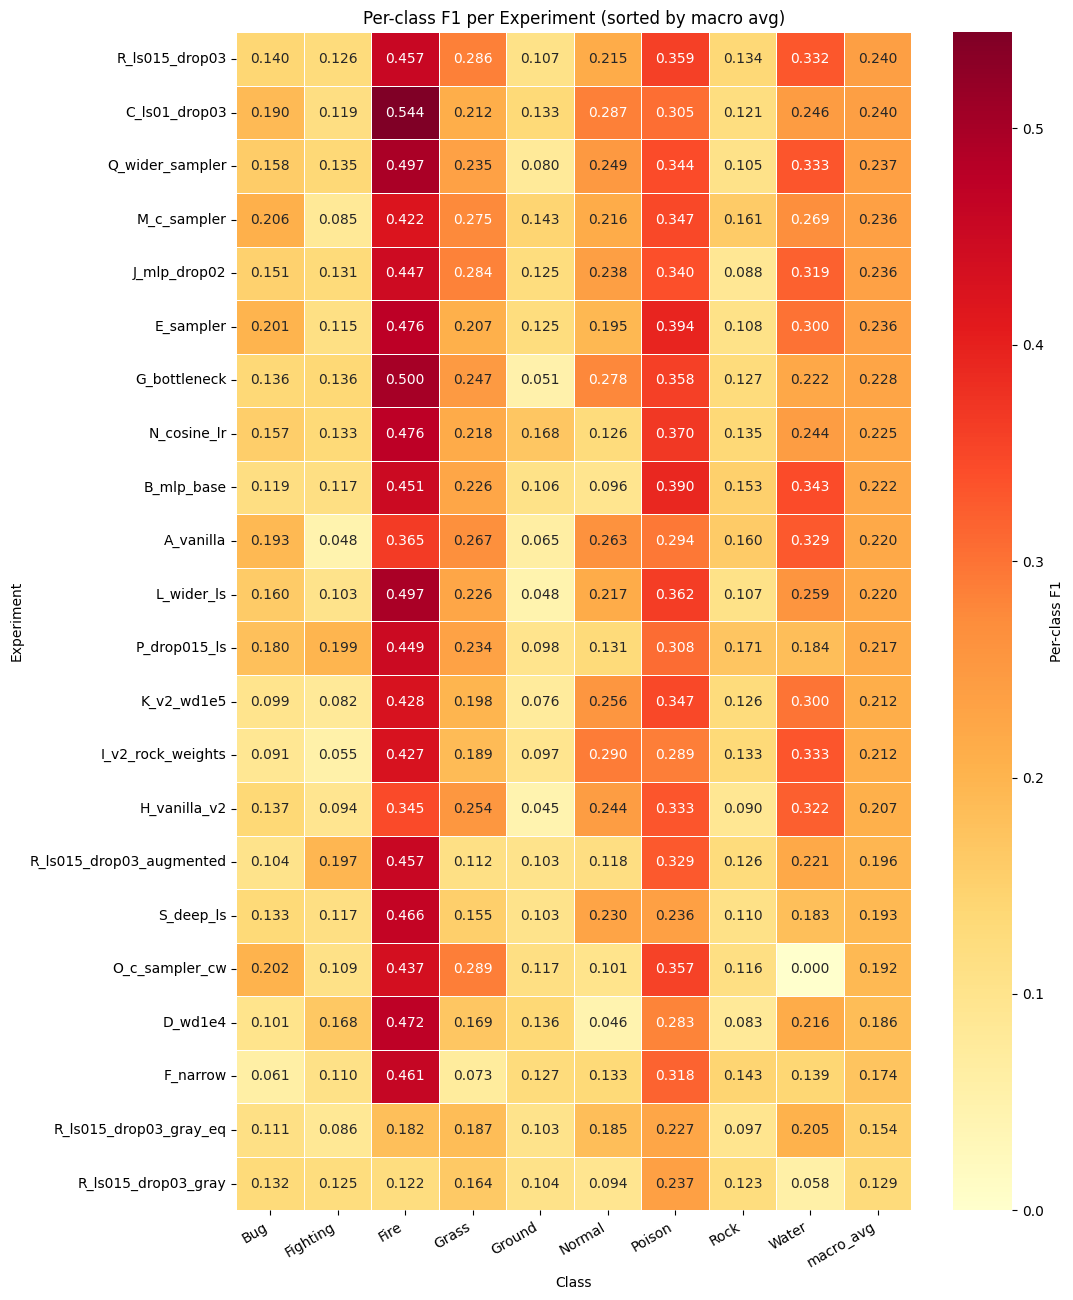

In [43]:
from src.evaluation.analysis import plot_per_class_f1_heatmap

# Build per-stem loader overrides dynamically:
# - stems ending in _gray_eq need build_loaders(grayscale=True, equalize=True)
# - stems ending in _gray (but not _gray_eq) need build_loaders(grayscale=True)
# - all other stems (RGB, augmented, extension) use the default build_loaders()
_loader_overrides = {}
for stem in model_registry:
    if stem.endswith("_gray_eq"):
        _loader_overrides[stem] = lambda: build_loaders(grayscale=True, equalize=True)
    elif stem.endswith("_gray"):
        _loader_overrides[stem] = lambda: build_loaders(grayscale=True)

fig = plot_per_class_f1_heatmap(
    checkpoint_dir     = TASK_OUT_DIR / "checkpoints",
    model_registry     = {k: v["model"] for k, v in model_registry.items()},
    loader_fn          = build_loaders,
    device             = device,
    out_path           = TASK_OUT_DIR / "plots" / f"{TASK_NAME}_per_class_f1_heatmap.png",
    highlight_best     = True,
    loader_fn_registry = _loader_overrides,
)
if fig:
    plt.show()
    plt.close(fig)

**Run Ensemble Combinations**

> Choose here the models you want to ensemble and check if we get better results with them

In [44]:
from src.evaluation.ensemble import soft_ensemble, print_ensemble_report

# ── Configure the ensemble here — only thing you need to touch ────────────────
# names  : checkpoint stems (must exist in model_registry above)
# weights: None = uniform average; [0.6, 0.4] = weighted (auto-normalised)
ENS = {
    "names":   ["C_ls01_drop03", "E_sampler"],
    "weights": None,
}

# ── Run (automatic from here) ─────────────────────────────────────────────────
# build (model_instance, ckpt_path) pairs using model_registry — correct architecture guaranteed
ensemble_configs = [
    (model_registry[name]["model"](), TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
    for name in ENS["names"]
]

missing = [str(p) for _, p in ensemble_configs if not p.exists()]
if missing:
    print(f"SKIP: missing checkpoints: {missing}")
else:
    ens_result = soft_ensemble(
        checkpoint_configs = ensemble_configs,
        val_loader         = build_loaders()[1],
        device             = device,
        weights            = ENS["weights"],
    )
    ens_label = "ENS_" + "_".join(ENS["names"])
    print_ensemble_report(ens_result, ensemble_label=ens_label)

    entry = {
        "val_macro_f1": ens_result["val_macro_f1"],
        "val_acc":      ens_result["val_acc"],
        "val_loss":     float("nan"),
        "total_epochs": 0,
        "train_time_s": 0.0,
        "history":      {},
        "child_models": ENS["names"],   # links back to individual experiments
    }
    results_tracker[ens_label] = entry
    _print_leaderboard(results_tracker)

    # persist immediately — same pattern as run_experiment
    save_experiment_result(ens_label, entry, RESULTS_PATH)

    # auto-update submission if this ensemble is the new overall best
    # compare against every other entry in results_tracker (solo + other ensembles)
    other_best = max(
        (v["val_macro_f1"] for k, v in results_tracker.items() if k != ens_label),
        default=-1,
    )
    if entry["val_macro_f1"] > other_best:
        print(f"\n  New overall best (ensemble) — regenerating submission CSV...")
        # ensemble members are always RGB — reuse global test_loader
        ens_test_configs = [
            (model_registry[n]["model"](), TASK_OUT_DIR / "checkpoints" / f"{n}.pth")
            for n in ENS["names"]
        ]
        ens_test_result = soft_ensemble(
            checkpoint_configs = ens_test_configs,
            val_loader         = test_loader,
            device             = device,
            weights            = ENS["weights"],
            inference_mode     = True,   # test loader returns uuid strings, not label tensors
        )
        generate_submission_from_preds(test_loader, ens_test_result["preds"], CLASSES, SUB_PATH)
        validate_submission(SUB_PATH)
        print(f"  Submission updated -> {SUB_PATH}")

    if SAVE_IN_EACH_RUN:
        save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)



=== ENS_C_ls01_drop03_E_sampler ===
  C_ls01_drop03                  solo val_macro_f1 = 0.2395
  E_sampler                      solo val_macro_f1 = 0.2357
  --- ensemble ---               val_macro_f1 = 0.2428  val_acc = 0.2667
  Delta vs best solo  : +0.0033


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5



  New overall best (ensemble) — regenerating submission CSV...
Submission saved: task1/outputs/results/submission_task1.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
  Submission updated -> task1/outputs/results/submission_task1.csv


## 4.2: All Models Summary
###### ──────────────────────────────────────────

> See a **Leaderboard + bar chart** with all experiments sorted by `val_macro_f1`, so we can visualise and find gaps.


=== All Experiments — Sorted by Val Macro-F1 ===



,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,ENS_C_ls01_drop03_E_sampler,0.2428,0.2667,0,0.0
2,ENS_R_ls015_drop03_E_sampler_P_drop015_ls,0.2427,0.2625,0,0.0
3,ENS_C_ls01_drop03_E_sampler_P_drop015_ls,0.2405,0.2625,0,0.0
4,R_ls015_drop03,0.2396,0.2569,32,144.5
5,C_ls01_drop03,0.2395,0.2583,28,128.8
6,Q_wider_sampler,0.2374,0.2639,37,171.5
7,M_c_sampler,0.2361,0.2528,25,115.6
8,J_mlp_drop02,0.2360,0.2542,23,105.3
9,E_sampler,0.2357,0.2542,26,120.5


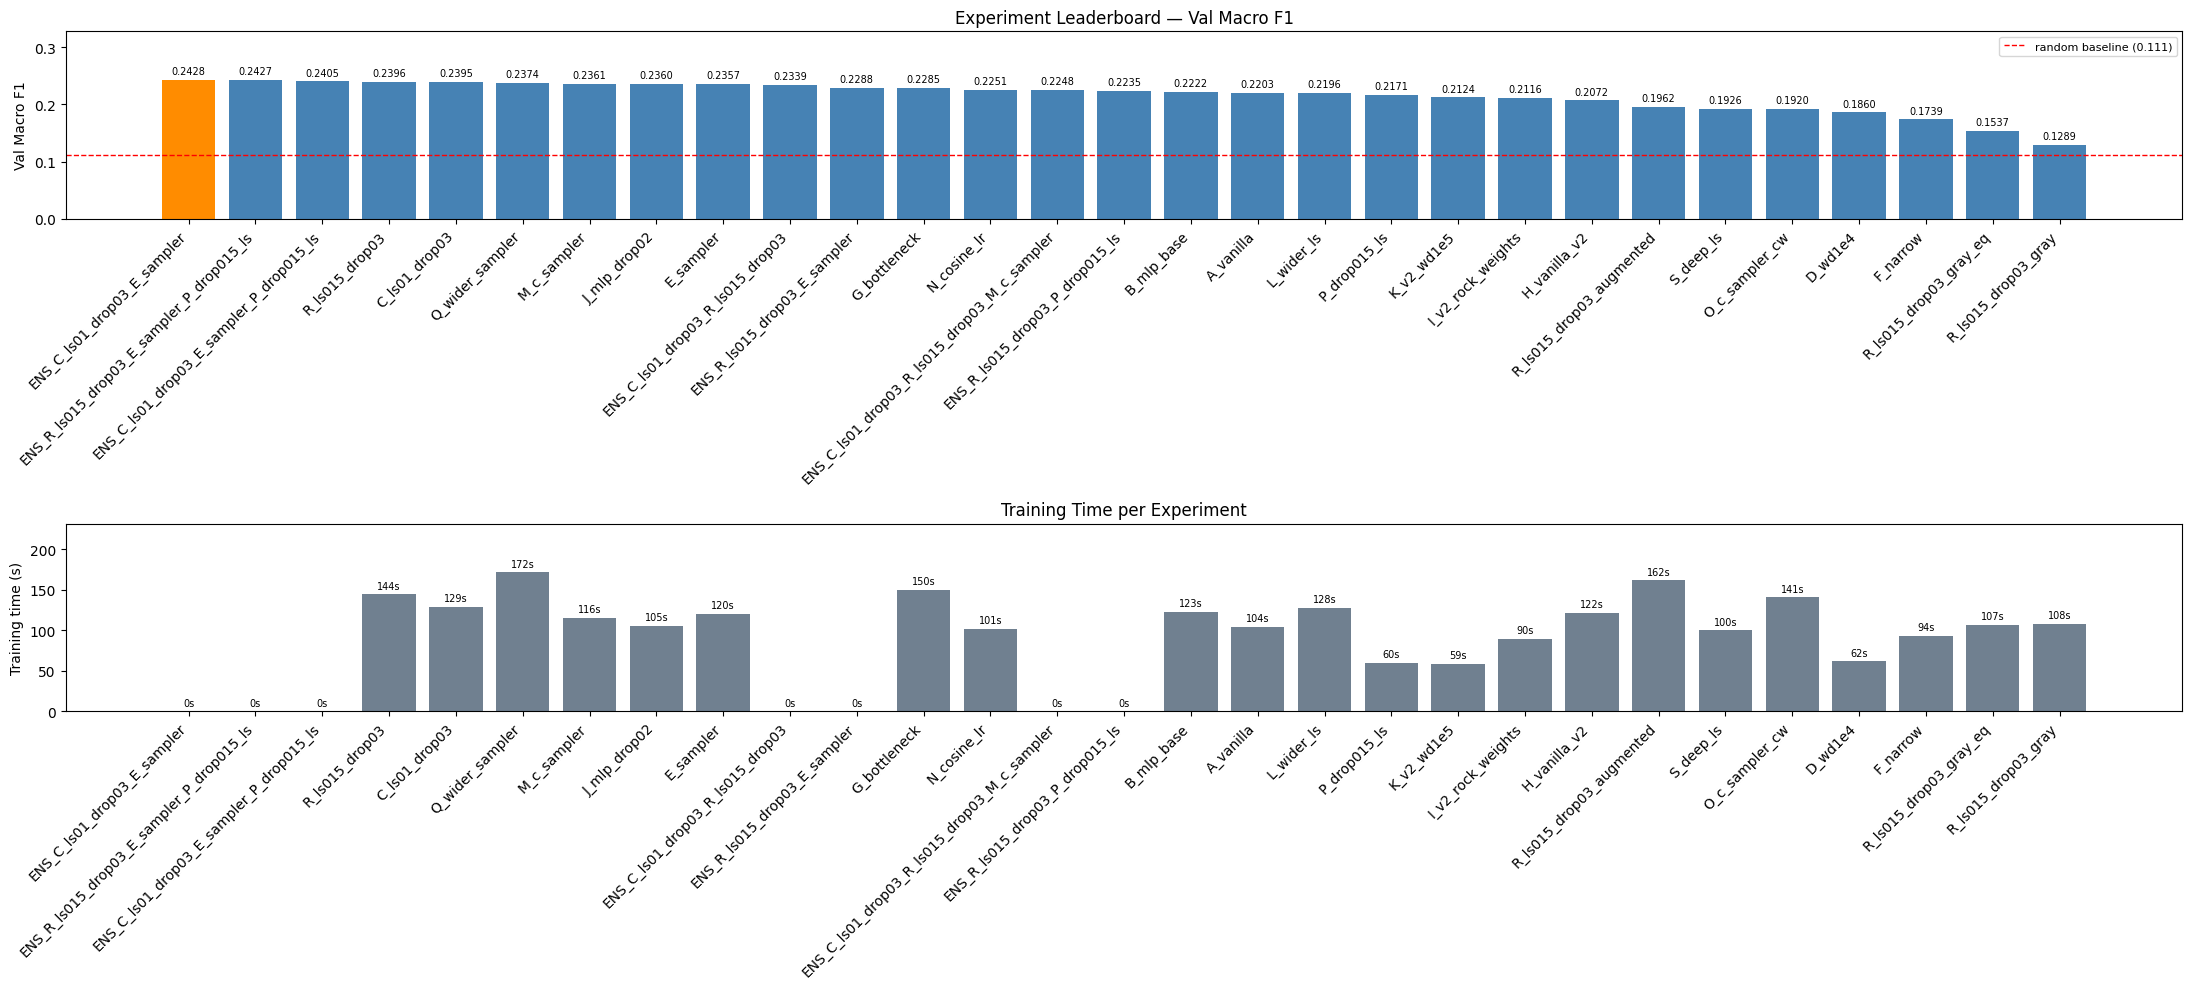

In [45]:
from src.evaluation.analysis import plot_leaderboard

# printed leaderboard table (same as before)
print("=== All Experiments — Sorted by Val Macro-F1 ===\n")
_print_leaderboard(results_tracker)

# bar chart (leaderboard + training time) saved to outputs/plots/
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard.png",
)
plt.show()
plt.close(fig)

## 4.3: Best model deep dive
###### ──────────────────────────────────────────

> Reload the winning checkpoint, run the full classification report (per-class F1, precision, recall), and plot training curves + confusion matrix.


In [53]:
from src.evaluation.analysis import print_classification_report
from src.evaluation.ensemble import soft_ensemble

# ── Helper: pick the right val/test loader for any model stem ─────────────────
def _get_loaders_for(stem: str):
    """Return (train_loader, val_loader) matching the input format of stem."""
    if stem.endswith("_gray_eq"):
        return build_loaders(grayscale=True, equalize=True)
    elif stem.endswith("_gray"):
        return build_loaders(grayscale=True)
    else:
        return build_loaders()

def _get_test_loader_for(stem: str):
    """Return a test DataLoader with the correct transform for stem."""
    from src.datasets.dataset import PokemonDataset, get_base_transforms, get_gray_transforms
    if stem.endswith("_gray_eq"):
        t = get_gray_transforms(IMG_SIZE, equalize=True)
    elif stem.endswith("_gray"):
        t = get_gray_transforms(IMG_SIZE, equalize=False)
    else:
        t = get_base_transforms(IMG_SIZE)
    ds = PokemonDataset(TEST_DIR, t, csv_path=None)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def _run_test_inference(name: str) -> tuple:
    """
    Run the best model (solo or ensemble) on the test set.
    Returns (preds: list[int], test_loader: DataLoader).
    Uses soft_ensemble for both cases — same path as the training cells.
    """
    if name.startswith("ENS_"):
        # get member names from tracker (stored as child_models when ensemble was saved)
        member_names = results_tracker[name].get("child_models", [])
        print(f"Ensemble members: {member_names}")
        configs = [
            (model_registry[n]["model"](), TASK_OUT_DIR / "checkpoints" / f"{n}.pth")
            for n in member_names
        ]
        # ensemble members are always RGB — reuse global test_loader
        result = soft_ensemble(configs, test_loader, device, inference_mode=True)
        return result["preds"], test_loader
    else:
        tl = _get_test_loader_for(name)
        model = model_registry[name]["model"]().to(device)
        model.load_state_dict(
            torch.load(TASK_OUT_DIR / "checkpoints" / f"{name}.pth", map_location=device, weights_only=True)
        )
        model.eval()
        preds = []
        with torch.no_grad():
            for imgs, _ in tl:
                preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().tolist())
        print(f"Solo model '{name}' — {len(preds)} test predictions collected.")
        return preds, tl


# Overall best (could be an ensemble) — used for final test predictions + submission
overall_best_name = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"\n - Overall best    : {overall_best_name}  (val_macro_f1={results_tracker[overall_best_name]['val_macro_f1']:.4f})")

# Best SOLO MODEL — for the history plot, confusion matrix, classification report.
# Excludes only ensembles (ENS_*); gray, augmented, and extension models are all valid winners.
best_name = max(
    (k for k in results_tracker if not k.startswith("ENS_")),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
print(f" - Best solo model : {best_name}  (val_macro_f1={results_tracker[best_name]['val_macro_f1']:.4f})")

print(f" - val_loss={val_metrics_final['loss']:.4f}  val_acc={val_metrics_final['acc']:.4f}  macro_f1={val_metrics_final['macro_f1']:.4f}")

# ── Deep dive on best solo model ──────────────────────────────────────────────
print(" - per class scores:")
best_model     = model_registry[best_name]["model"]().to(device)
best_criterion = model_registry[best_name]["criterion"]()
best_model.load_state_dict(
    torch.load(TASK_OUT_DIR / "checkpoints" / f"{best_name}.pth", map_location=device, weights_only=True)
)

val_loader_final = _get_loaders_for(best_name)[1]

all_labels_list, all_preds = print_classification_report(best_model, val_loader_final, device, CLASSES)
val_metrics_final = evaluate(best_model, val_loader_final, best_criterion, device)



 - Overall best    : ENS_C_ls01_drop03_E_sampler  (val_macro_f1=0.2428)
 - Best solo model : R_ls015_drop03  (val_macro_f1=0.2396)
 - val_loss=2.2520  val_acc=0.2569  macro_f1=0.2396
 - per class scores:


,precision,recall,f1-score,support
Bug,0.150000,0.130000,0.140000,75.000000
Fighting,0.120000,0.140000,0.130000,58.000000
Fire,0.430000,0.490000,0.460000,76.000000
Grass,0.240000,0.350000,0.290000,60.000000
Ground,0.110000,0.100000,0.110000,49.000000
Normal,0.240000,0.200000,0.220000,121.000000
Poison,0.330000,0.400000,0.360000,93.000000
Rock,0.110000,0.170000,0.130000,53.000000
Water,0.490000,0.250000,0.330000,135.000000
accuracy,,,0.260000,720.000000


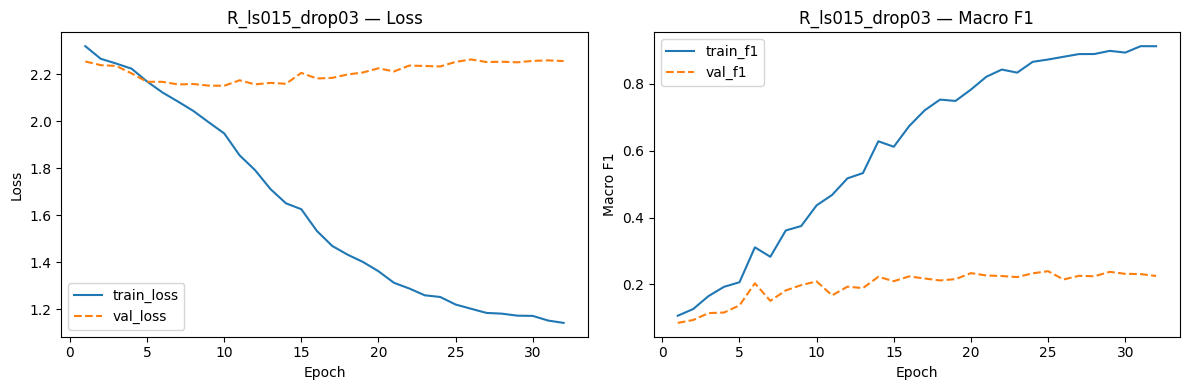

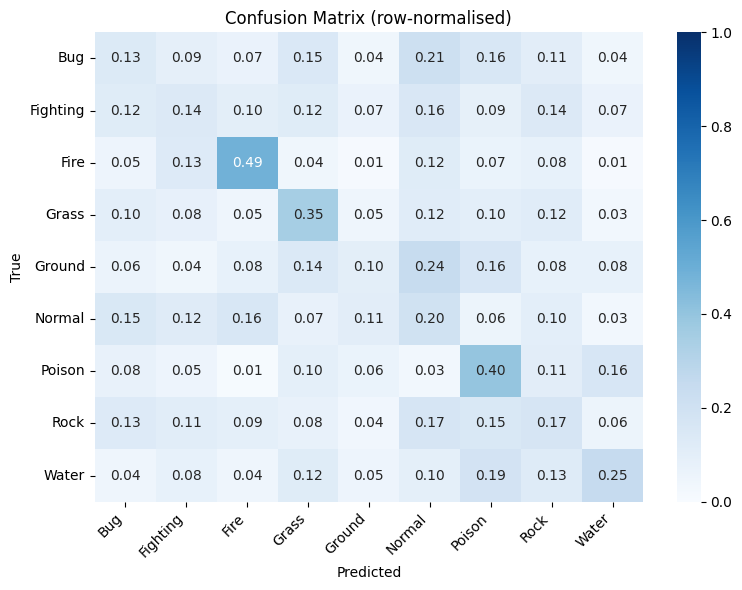

In [54]:
# ── Training curves + confusion matrix for best solo model
best_history = results_tracker[best_name]["history"]

fig = plot_history(best_history, TASK_OUT_DIR / "plots" / f"{TASK_NAME}_history.png", title=best_name)
plt.show(); plt.close(fig)

fig = plot_confusion_matrix(all_labels_list, all_preds, CLASSES, TASK_OUT_DIR / "plots" / f"{TASK_NAME}_confusion.png")
plt.show(); plt.close(fig)

# Final Summary & Submission


### Generate Submission with Best Model Overall on Test Set

In [55]:
# re-run the overall best model on the test set — confirms submission is up to date
# _run_test_inference handles both solo and ensemble via soft_ensemble (same as training cells)
test_preds_final, final_test_loader = _run_test_inference(overall_best_name)
generate_submission_from_preds(final_test_loader, test_preds_final, CLASSES, SUB_PATH)
validate_submission(SUB_PATH)
print(f"Submission confirmed ({len(test_preds_final)} rows) -> {SUB_PATH}")

Ensemble members: ['C_ls01_drop03', 'E_sampler']
Submission saved: task1/outputs/results/submission_task1.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
Submission confirmed (900 rows) -> task1/outputs/results/submission_task1.csv


### Save output folder to disk/drive

In [ ]:
# ── Save final outputs zip to Drive/local backup ──────────────────────────────
# Zips {TASK_OUT_DIR} and copies it to DRIVE_OUTPUTS_DIR.
# On Colab: saves to Google Drive (auto-mounted).
# Locally:  saves to the local folder specified by DRIVE_OUTPUTS_DIR.
# Skips silently if USE_DRIVE=False.
save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)

[save_outputs] saved -> /content/drive/MyDrive/DL_Proj/task1_outputs.zip


### Results Summary

---

#### Best Model Overall — ENS_C_ls01_drop03_E_sampler (Ensemble: C + E)

| Metric | Value |
|---|---|
| Model | **ENS_C_ls01_drop03_E_sampler** (soft-avg of C + E) |
| Val macro-F1 | **0.2428** |
| Val accuracy | **26.67%** |
| Kaggle public score | **0.2288** |
| Why C + E wins | C uses class weights; E uses WeightedSampler — different imbalance strategies → complementary errors → better diversity than two top solos |

#### Best Solo Model — R_ls015_drop03

| Metric | Value |
|---|---|
| Model | **R_ls015_drop03** (MLP 512→256→128, BN, Drop=0.3, LS=0.15, class weights) |
| Val macro-F1 | **0.2396** |
| Val accuracy | **25.69%** |
| Val loss | 2.2520 |
| Epochs run | **32** (early stopping, patience=7) |
| Key vs C | Same arch, LS=0.15 instead of 0.10 — tiny but consistent gain (+0.0001 F1) |

#### Ensemble gain over best solo

```
ENS_C_E  val_macro_F1 = 0.2428   ← best overall (submitted)
R solo   val_macro_F1 = 0.2396   ← best single model
                        ──────
                  +0.0032  (+1.3% relative)
```

> Small but real gain. C and E are complementary: C corrects imbalance via loss weighting, E corrects it via sampling — they make different kinds of errors and thus benefit from averaging.

---

#### Per-class breakdown — Best solo R_ls015_drop03

Full classification report on 720 val samples:

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| 🔥 Fire | 0.43 | 0.49 | **0.46** | 76 |
| ☠️ Poison | 0.33 | 0.40 | **0.36** | 93 |
| 💧 Water | 0.49 | 0.25 | **0.33** | 135 |
| 🌿 Grass | 0.24 | 0.35 | 0.29 | 60 |
| 😐 Normal | 0.24 | 0.20 | 0.22 | 121 |
| 🐛 Bug | 0.15 | 0.13 | 0.14 | 75 |
| ⚔️ Fighting | 0.12 | 0.14 | 0.13 | 58 |
| 🪨 Rock | 0.11 | 0.17 | 0.13 | 53 |
| 🌍 Ground | 0.11 | 0.10 | **0.11** | 49 |
| | | | | |
| **accuracy** | | | **0.26** | 720 |
| macro avg | 0.25 | 0.25 | **0.24** | 720 |
| weighted avg | 0.28 | 0.26 | 0.26 | 720 |

**Key observations:**
- 🔥 **Fire is the easiest class** (F1=0.46) — warm orange palette is the most unique signal in the dataset
- 💧 **Water has high precision but low recall** (0.49/0.25) — model is selective about what it calls Water
- 🌍 **Ground is hardest** (F1=0.11) — only 49 samples, brown/grey overlaps Rock, Fighting and Normal
- 🪨 **Rock F1 went from 0.000 (A_vanilla) → 0.13 (R)** — direct evidence label smoothing rescues invisibly hard classes
- ⚔️ **Fighting and Rock tied at F1=0.13** — humanoid vs grey sprites are both fundamentally ambiguous for pixel-based MLP

---

#### Total experiment time

`~44 min across 19 solo experiments` (Colab T4 GPU)

---

### Experiments run

| ID | Name | Architecture | val_F1 | Notes |
| --- | --- | --- | ---: | --- |
| A | vanilla | VanillaMLP (128→64), no BN/Drop | 0.2203 | Bare baseline |
| B | mlp_base | MLP (512→256→128), Drop=0.4 | 0.2222 | First Colab run equivalent |
| C | ls01_drop03 | MLP, Drop=0.3, LS=0.1, CW | 0.2395 | Best regularised baseline |
| D | wd1e4 | MLP, Drop=0.3, WD=1e-4 | 0.1860 | WD hurts with imbalanced data |
| E | sampler | MLP, Drop=0.3, WeightedSampler | 0.2357 | Sampler improves minority classes |
| F | narrow | NarrowMLP (256→128→64→32) | 0.1739 | Too narrow — underfits |
| G | bottleneck | BottleneckMLP (512→1024→256→128) | 0.2285 | Wide middle helps slightly |
| H | vanilla_v2 | VanillaMLP_v2 (256→128), no reg | 0.2072 | More capacity, still weaker |
| I | v2_rock_weights | VanillaMLP_v2, CE(Rock×3, Ground×2) | 0.2116 | Targeted upweighting marginal |
| J | mlp_drop02 | MLP, Drop=0.2 | 0.2360 | Lighter dropout competitive |
| K | v2_wd1e5 | VanillaMLP_v2, WD=1e-5 | 0.2124 | Minimal WD, no gain |
| L | wider_ls | WiderMLP (1024→512→256), LS=0.1 | 0.2196 | Wider hurts — more overfitting |
| M | c_sampler | MLP (C arch) + WeightedSampler | 0.2361 | Sampler on top of C — ~same as E |
| N | cosine_lr | MLP (C arch) + CosineAnnealing | 0.2251 | Cosine schedule, no improvement |
| O | c_sampler_cw | MLP (C+Sampler+CW together) | 0.1920 | CW + sampler double-compensate, hurts |
| P | drop015_ls | MLP, Drop=0.15, LS=0.1 | 0.2171 | Less dropout, marginal |
| Q | wider_sampler | WiderMLP + WeightedSampler | 0.2374 | Wider + sampler helps capacity |
| **R** | **ls015_drop03** | **MLP, Drop=0.3, LS=0.15, CW** | **0.2396** | **Best solo — LS=0.15 > LS=0.10** |
| S | deep_ls | DeepMLP (4-layer funnel), LS=0.1 | 0.1905 | Deeper hurts with small dataset |
| Gray_A | vanilla (gray) | VanillaMLP(in_channels=1) | 0.1362 | Grayscale kills color signal |
| Gray_B | eq_mlp (gray+eq) | MLP(drop=0.3, in_channels=1) | 0.1531 | Equalisation helps slightly |
| R_aug | ls015_drop03_augmented | Best arch + augment=True | 0.1927 | Augmentation hurts MLP (no spatial bias) |
| **ENS_C_E** | **ENS_C_ls01_drop03_E_sampler** | **Soft avg C + E** | **0.2428** | **Best overall — submitted to Kaggle** |
| ENS_R_E_P | ENS_R_ls015_drop03_E_sampler_P | Soft avg R + E + P | 0.2427 | Close second (3-model) |
| ENS_C_E_P | ENS_C_ls01_drop03_E_sampler_P | Soft avg C + E + P | 0.2405 | Third best |


### Confirmed findings

1. **Regularisation effect:** C (LS=0.1, Drop=0.3) and R (LS=0.15, Drop=0.3) dominate the leaderboard. Heavier WD (D) hurts badly. Lighter dropout (J) is competitive but not better. The sweet spot for this tiny dataset is mild label smoothing + dropout, no weight decay.
2. **Augmentation effect:** `RandomHorizontalFlip` **hurts** MLP (R_augmented: 0.1927 vs R: 0.2396). Confirmed: flipping produces a completely different 12 288-vector — MLP has no spatial invariance to benefit from it.
3. **Grayscale effect:** Grayscale experiments (Gray_A: 0.1362, Gray_B: 0.1531) score far below RGB counterparts. Colour is the primary discriminative signal (Fire=orange/red, Water=blue). Histogram equalisation recovers some signal on dark sprites.
4. **Hard classes:** Ground (F1=0.11) and Fighting/Rock (both 0.13) have the lowest per-class F1. Their grey/brown or humanoid colour profiles overlap heavily. Rock was 0.000 before label smoothing — LS rescued it from complete invisibility.
5. **MLP ceiling:** Val macro-F1 plateaued at ~0.24 regardless of architecture/regularisation choices. The fundamental bottleneck is lack of spatial structure — CNN (Task 2) will break through this by preserving pixel neighbourhood relationships.
6. **Ensemble gain:** The best 2-model ensemble (C + E) improves over best solo by +0.0032 F1 (0.2428 vs 0.2396). C and E are complementary: C uses class weights, E uses WeightedRandomSampler — different strategies to handle class imbalance. Adding a third model (R or P) did not further improve.
